# Stock Price Prediction with ARIMA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import shap
import xgboost as xgb
from sklearn.metrics import r2_score
from scipy.optimize import minimize
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Thesis_Data/Data_with_VV.xlsx').drop(columns = ['divCash', 'splitFactor', 'Sector',
                                                                                'adjHigh', 'adjLow', 'adjOpen', 'adjVolume'])

df = df[df['date']>= '2021-01-01']

df['target'] = df.groupby('ticker')['adjClose'].transform(lambda x: x / x.shift(20) * 100 - 100)
df['target_for_test'] =  df.groupby('ticker')['adjClose'].transform(lambda x: x.shift(-20) / x * 100 - 100)
df = df.dropna()

In [ ]:
df

,date,close,high,low,open,volume,adjClose,ticker
2769,2021-01-04,118.64,120.0900,117.110,118.94,2030667,115.337656,A
2770,2021-01-05,119.61,120.3200,118.065,118.48,2343967,116.280656,A
2771,2021-01-06,122.89,123.8800,118.210,118.69,2428483,119.469357,A
2772,2021-01-07,126.16,127.4800,124.110,124.33,1775882,122.648337,A
2773,2021-01-08,127.06,127.6404,125.850,126.49,1577237,123.523285,A
...,...,...,...,...,...,...,...,...
169615,2025-04-24,25.50,25.7400,25.225,25.42,4047898,25.500000,WY
169616,2025-04-25,24.81,25.4750,24.740,25.22,4584506,24.810000,WY
169617,2025-04-28,25.57,25.6400,24.750,24.76,7708788,25.570000,WY
169618,2025-04-29,25.79,25.8600,25.360,25.36,5244818,25.790000,WY


In [ ]:
def train_test_split(df, date_threshold = '2024-04-30'):
    train = df[df['date'] <= date_threshold]
    #.drop(columns = ['date'])
    test = df[df['date'] > date_threshold]
    #.drop(columns = ['date'])
    return train, test

train, test = train_test_split(df)

# Testing for stationarity

In [ ]:
for ticker in train['ticker'].unique():
    print(f"\n===========Ticker: {ticker}===========")

    # Make a copy to avoid SettingWithCopyWarning
    data = train[train['ticker'] == ticker].copy()
    data = data.sort_values('date')

    result_original = adfuller(data["adjClose"])
    print(f"ADF Statistic (Original): {result_original[0]:.4f}")
    print(f"p-value (Original): {result_original[1]:.4f}")

    if result_original[1] < 0.05:
        print("Interpretation: The original series is Stationary.\n")
    else:
        print("Interpretation: The original series is Non-Stationary.\n")

    # Apply first-order differencing
    data['adjClose_Diff'] = data['adjClose'].diff()

    # Perform the ADF test on the differenced series
    result_diff = adfuller(data["adjClose_Diff"].dropna())
    print(f"ADF Statistic (Differenced): {result_diff[0]:.4f}")
    print(f"p-value (Differenced): {result_diff[1]:.4f}")

    if result_diff[1] < 0.05:
        print("Interpretation: The differenced series is Stationary.")
    else:
        print("Interpretation: The differenced series is Non-Stationary.")

    print('===============================\n')



===========Ticker: A===========
ADF Statistic (Original): -2.4497
p-value (Original): 0.1282
Interpretation: The original series is Non-Stationary.

ADF Statistic (Differenced): -29.2622
p-value (Differenced): 0.0000
Interpretation: The differenced series is Stationary.


===========Ticker: ABT===========
ADF Statistic (Original): -2.6178
p-value (Original): 0.0894
Interpretation: The original series is Non-Stationary.

ADF Statistic (Differenced): -28.5648
p-value (Differenced): 0.0000
Interpretation: The differenced series is Stationary.


===========Ticker: ADM===========
ADF Statistic (Original): -2.0429
p-value (Original): 0.2681
Interpretation: The original series is Non-Stationary.

ADF Statistic (Differenced): -29.5304
p-value (Differenced): 0.0000
Interpretation: The differenced series is Stationary.


===========Ticker: AES===========
ADF Statistic (Original): -1.7795
p-value (Original): 0.3907
Interpretation: The original series is Non-Stationary.

ADF Statistic (Difference

In [ ]:
for ticker in train['ticker'].unique():
    print(f"\n===========Ticker: {ticker}===========")

    # Make a copy to avoid SettingWithCopyWarning
    data = train[train['ticker'] == ticker].copy()
    data = data.sort_values('date')

    result_original = adfuller(data["target"])
    print(f"ADF Statistic (Original): {result_original[0]:.4f}")
    print(f"p-value (Original): {result_original[1]:.4f}")

    if result_original[1] < 0.05:
        print("Interpretation: The original series is Stationary.\n")
    else:
        print("Interpretation: The original series is Non-Stationary.\n")

    # Apply first-order differencing
    data['target_Diff'] = data['target'].diff()

    # Perform the ADF test on the differenced series
    result_diff = adfuller(data["target_Diff"].dropna())
    print(f"ADF Statistic (Differenced): {result_diff[0]:.4f}")
    print(f"p-value (Differenced): {result_diff[1]:.4f}")

    if result_diff[1] < 0.05:
        print("Interpretation: The differenced series is Stationary.")
    else:
        print("Interpretation: The differenced series is Non-Stationary.")

    print('===============================\n')



===========Ticker: A===========
ADF Statistic (Original): -4.7296
p-value (Original): 0.0001
Interpretation: The original series is Stationary.

ADF Statistic (Differenced): -9.3993
p-value (Differenced): 0.0000
Interpretation: The differenced series is Stationary.


===========Ticker: ABT===========
ADF Statistic (Original): -4.0266
p-value (Original): 0.0013
Interpretation: The original series is Stationary.

ADF Statistic (Differenced): -11.3825
p-value (Differenced): 0.0000
Interpretation: The differenced series is Stationary.


===========Ticker: ADM===========
ADF Statistic (Original): -4.3912
p-value (Original): 0.0003
Interpretation: The original series is Stationary.

ADF Statistic (Differenced): -9.2305
p-value (Differenced): 0.0000
Interpretation: The differenced series is Stationary.


===========Ticker: AES===========
ADF Statistic (Original): -4.1109
p-value (Original): 0.0009
Interpretation: The original series is Stationary.

ADF Statistic (Differenced): -10.3791
p-val

# ACF


===========Ticker: A===========


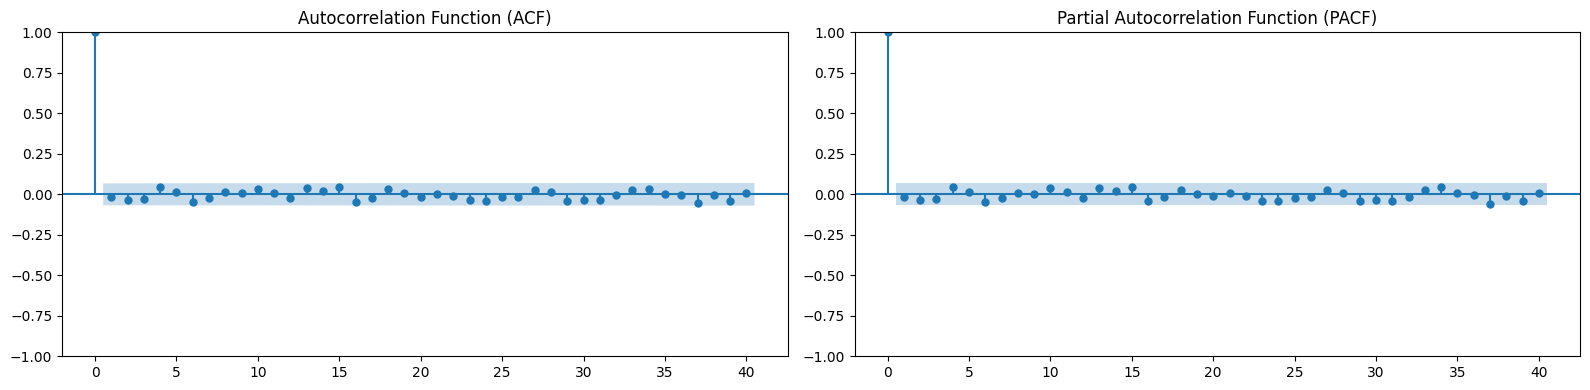


===========Ticker: ABT===========


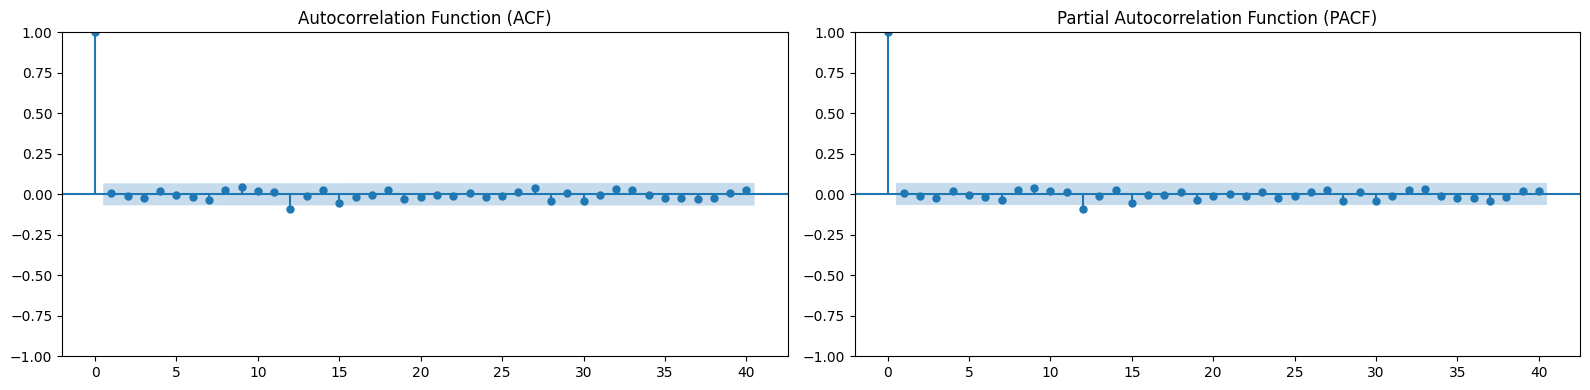


===========Ticker: ADM===========


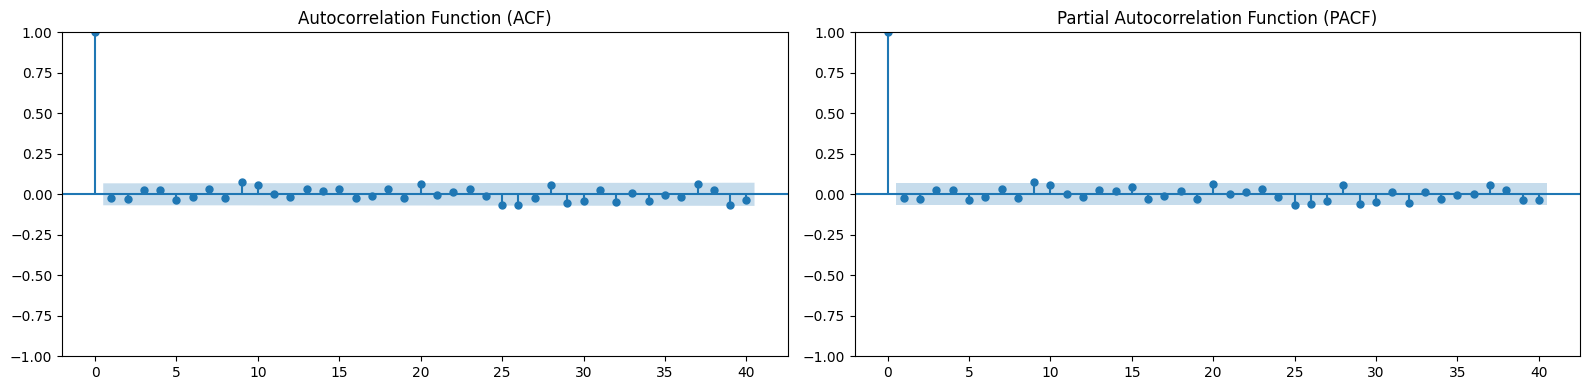


===========Ticker: AES===========


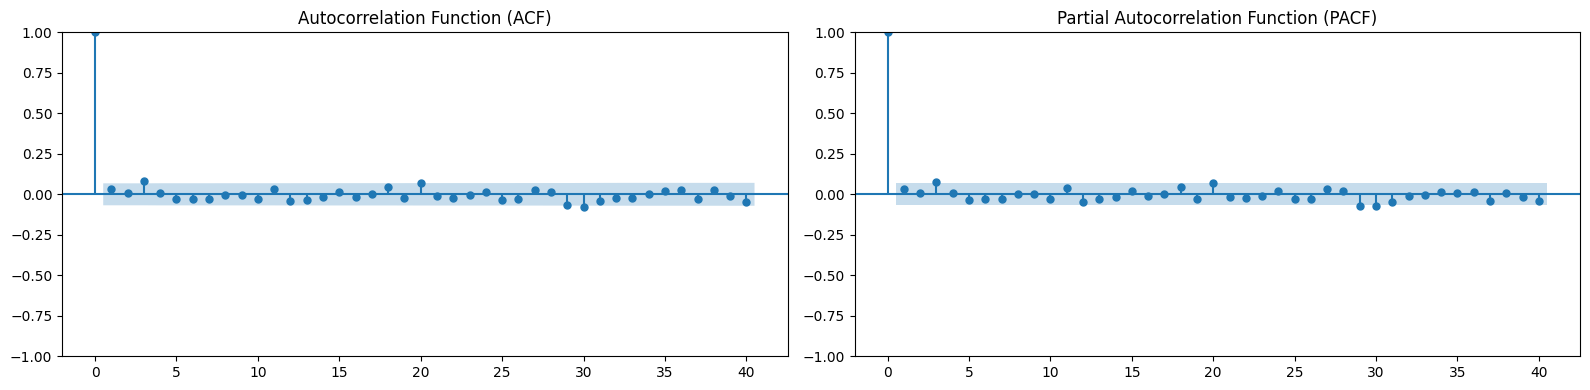


===========Ticker: AMZN===========


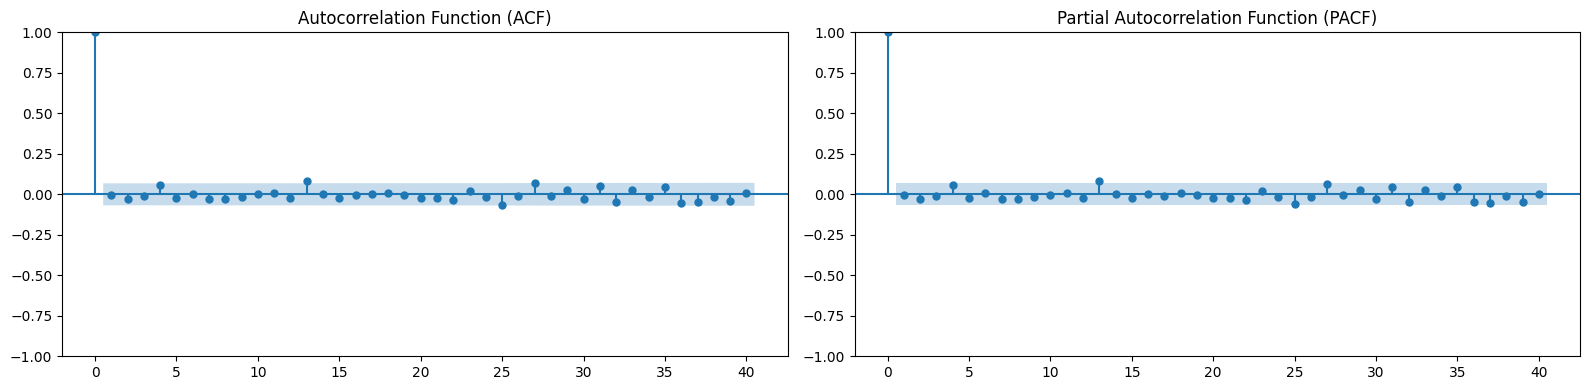


===========Ticker: APA===========


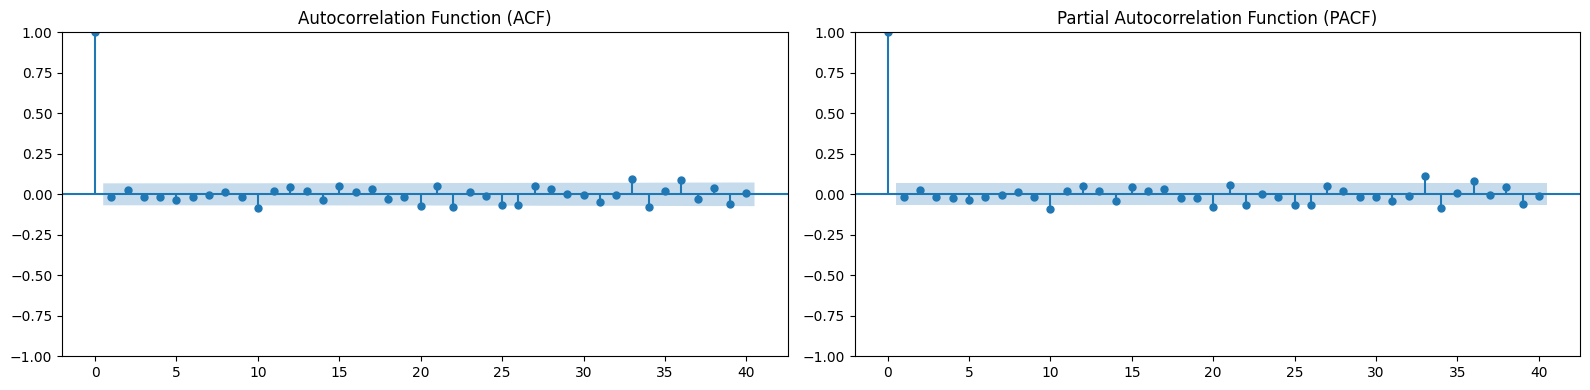


===========Ticker: APD===========


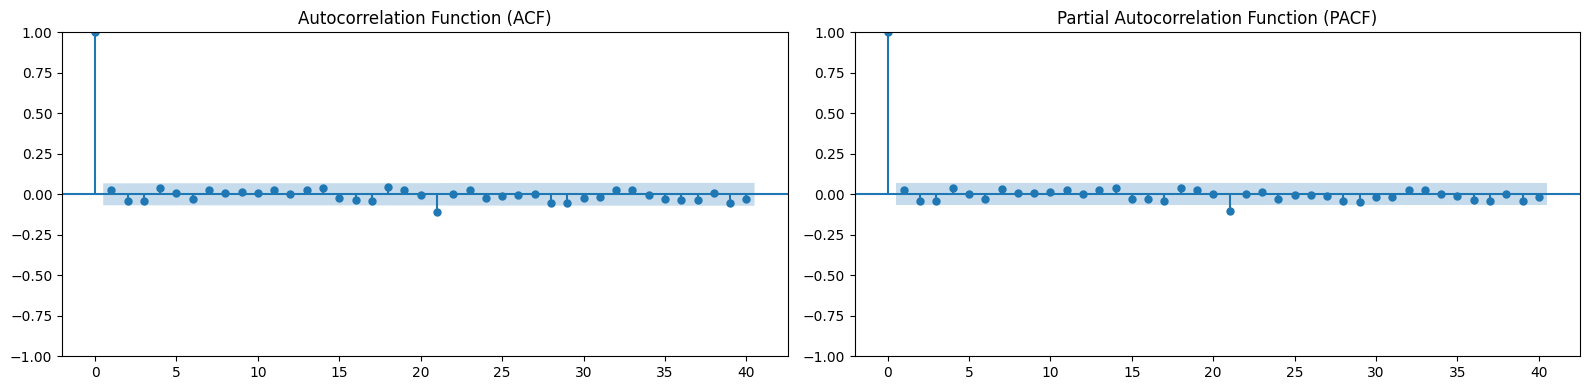


===========Ticker: BA===========


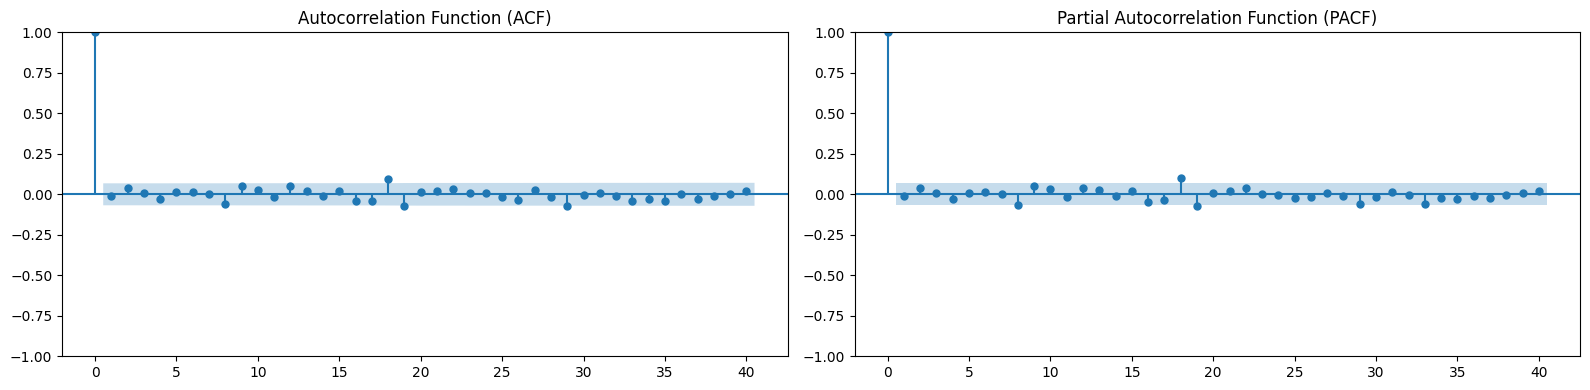


===========Ticker: BAC===========


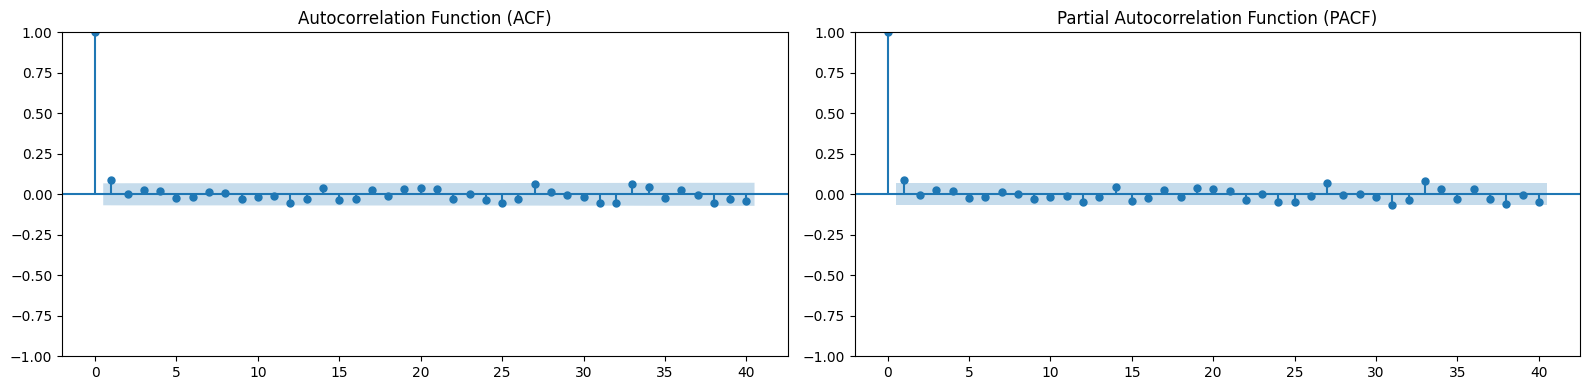


===========Ticker: BALL===========


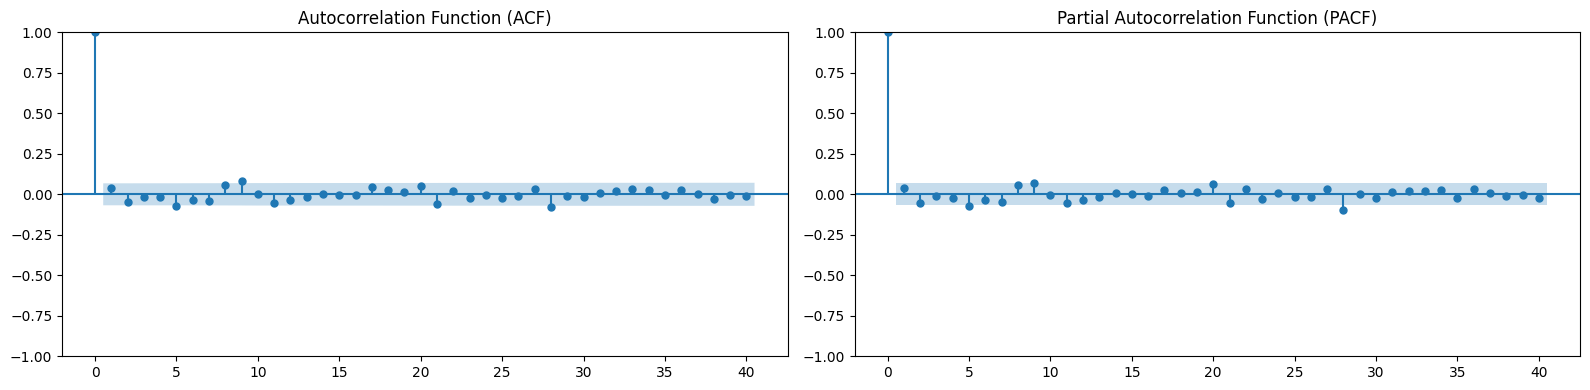


===========Ticker: BBY===========


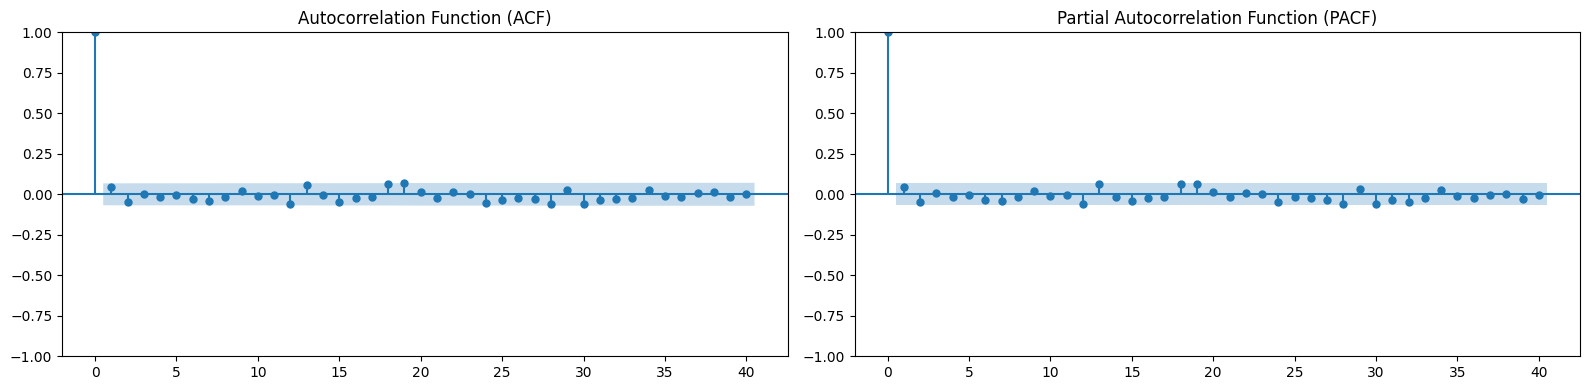


===========Ticker: CBRE===========


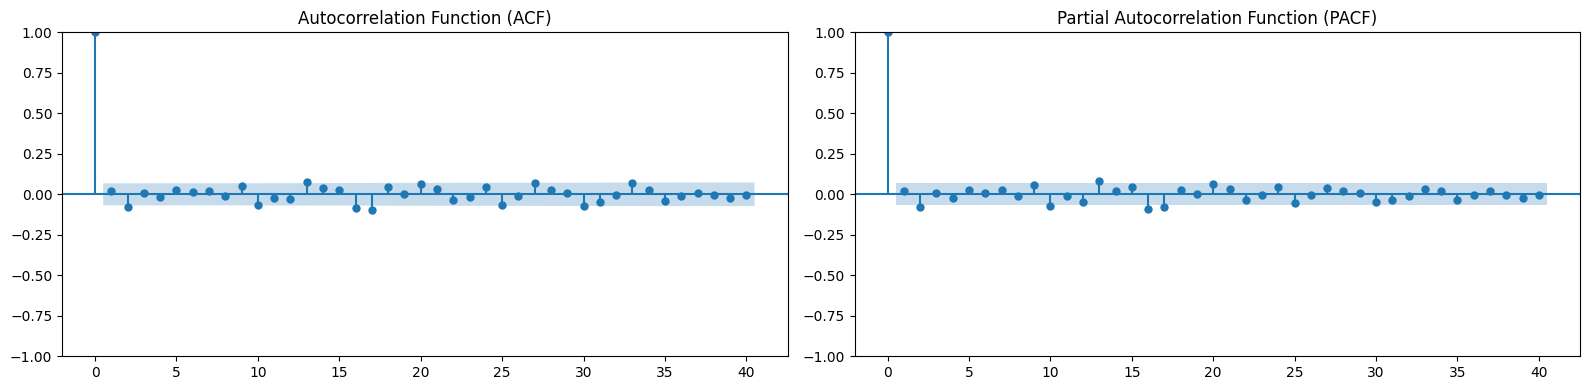


===========Ticker: CMCSA===========


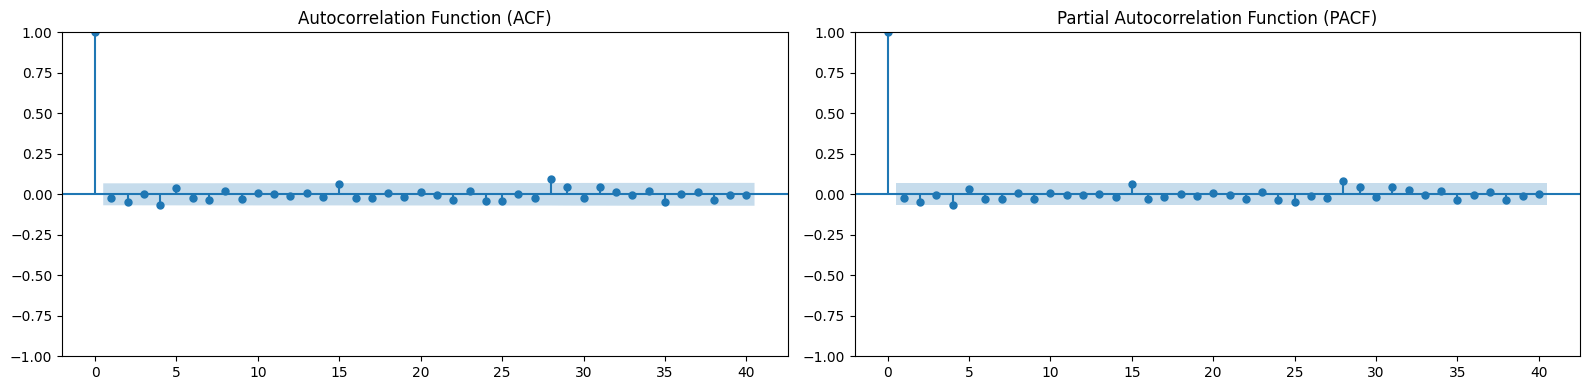


===========Ticker: CNP===========


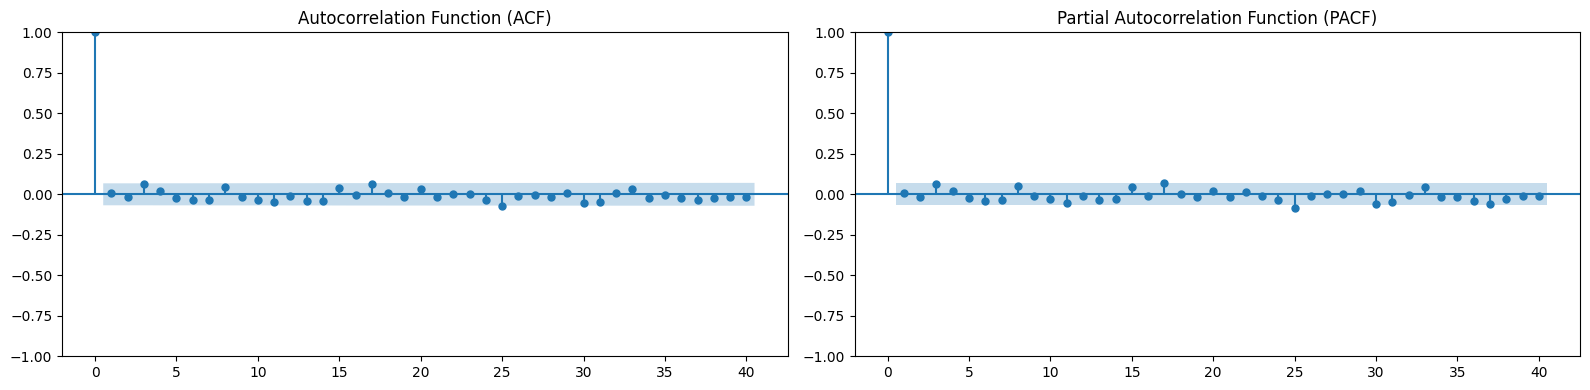


===========Ticker: CTSH===========


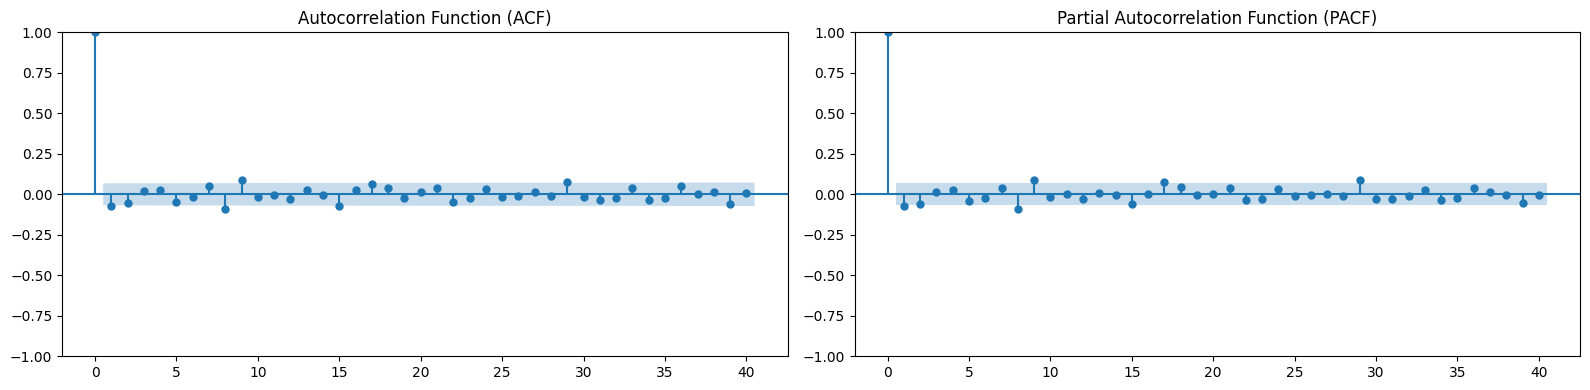


===========Ticker: EA===========


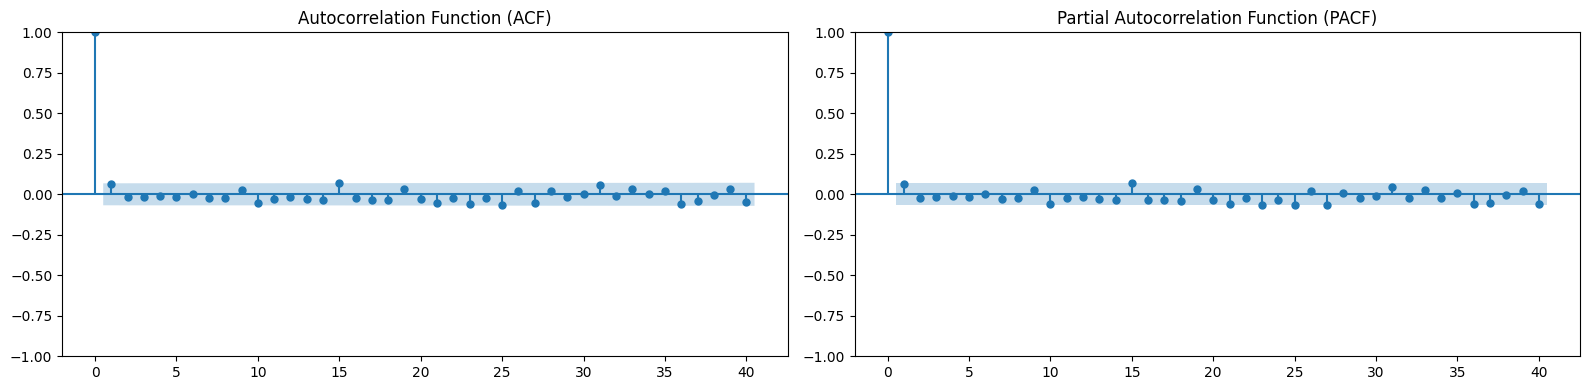


===========Ticker: EMR===========


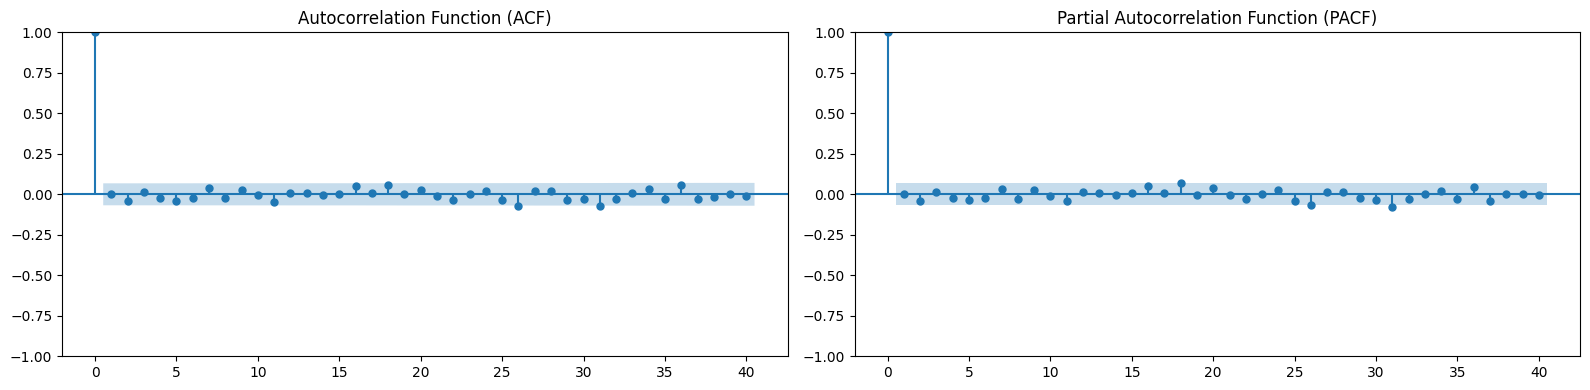


===========Ticker: FI===========


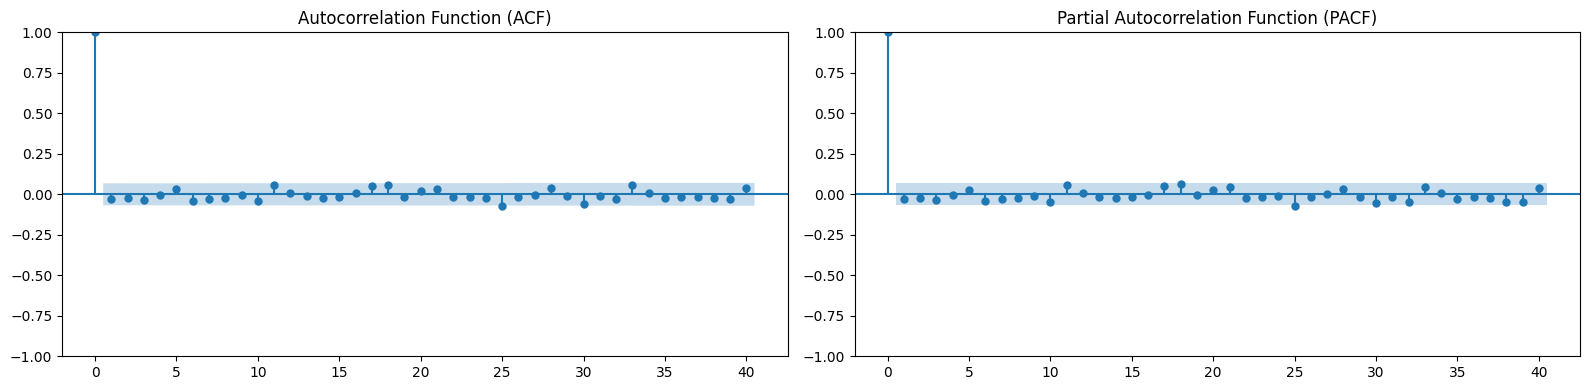


===========Ticker: GLW===========


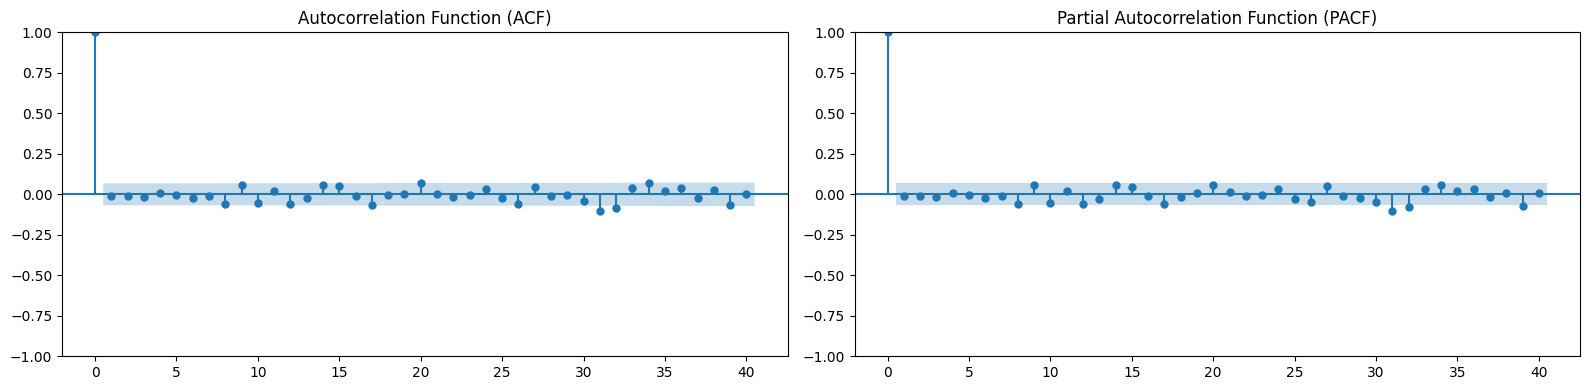


===========Ticker: GOOG===========


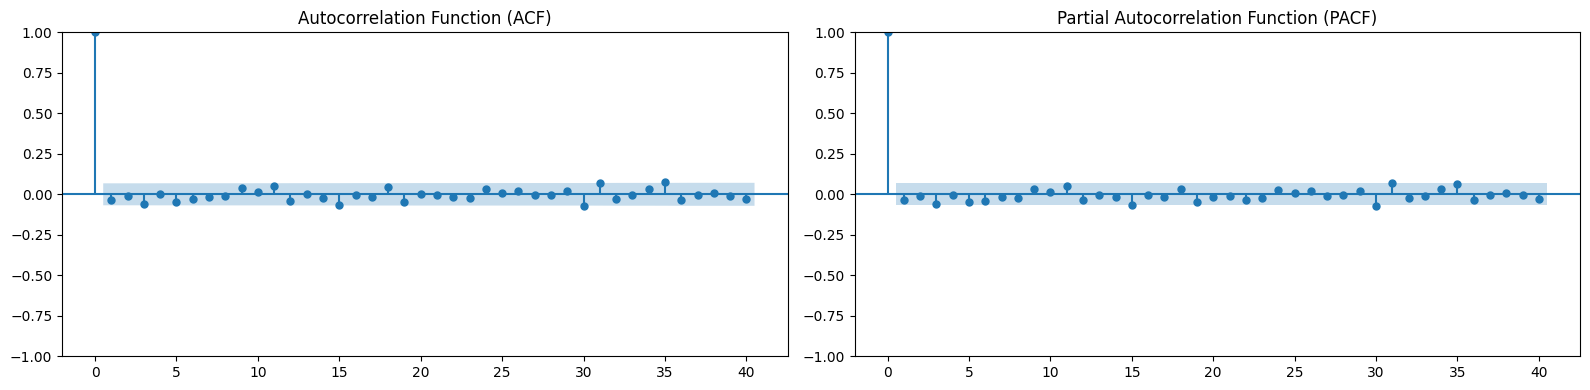


===========Ticker: HES===========


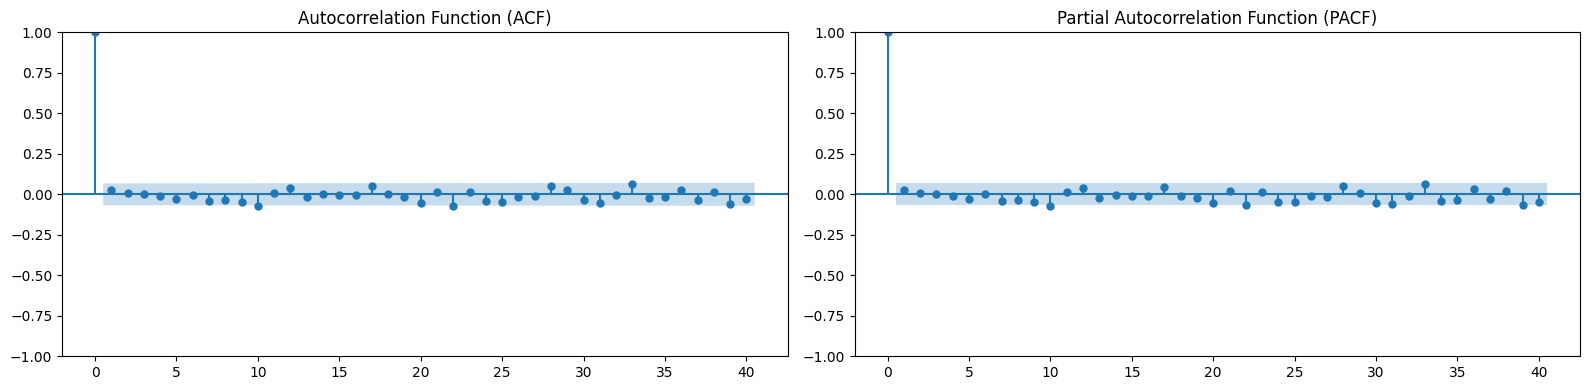


===========Ticker: KIM===========


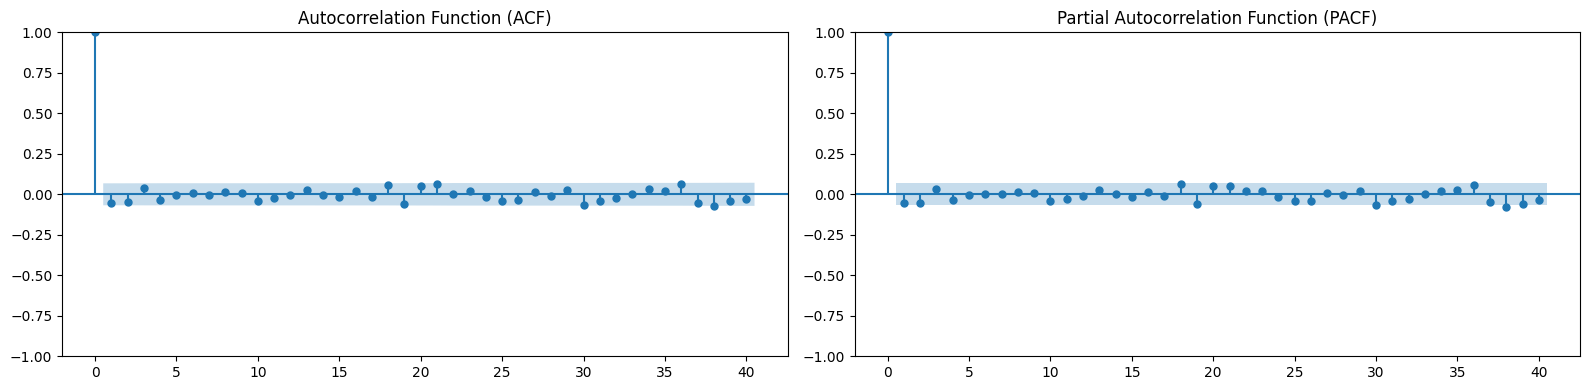


===========Ticker: NEE===========


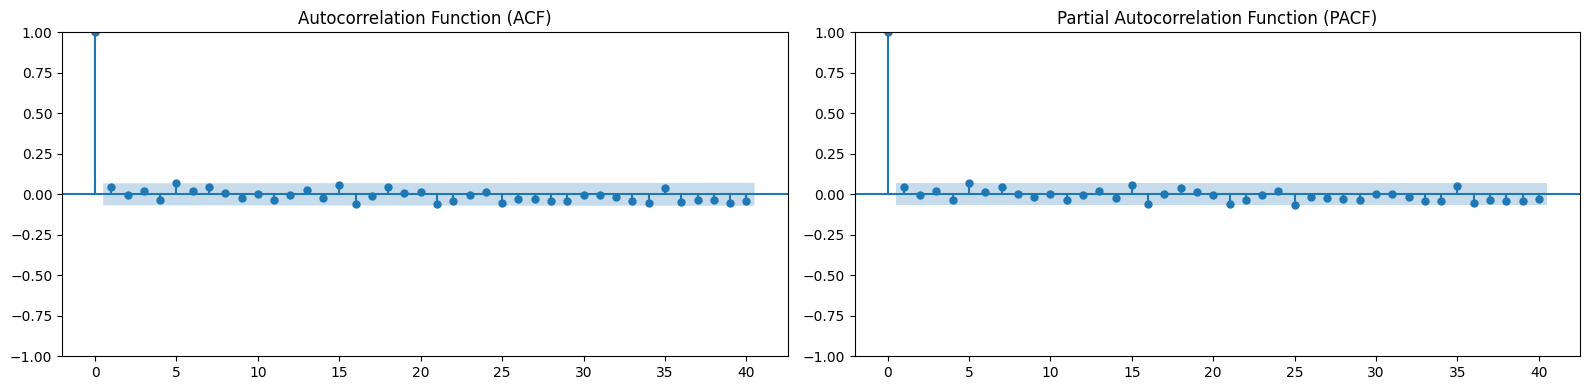


===========Ticker: NEM===========


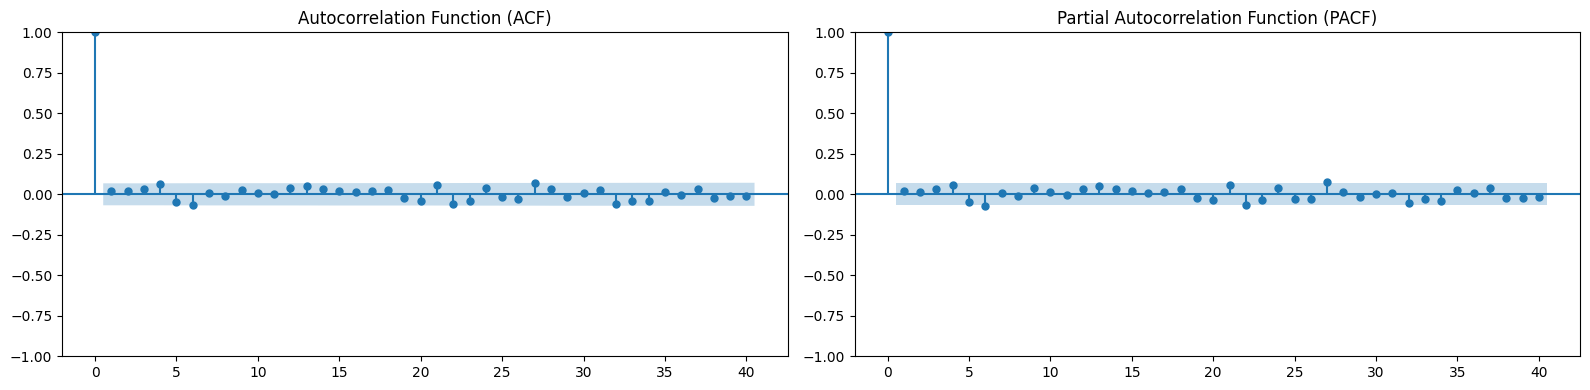


===========Ticker: NSC===========


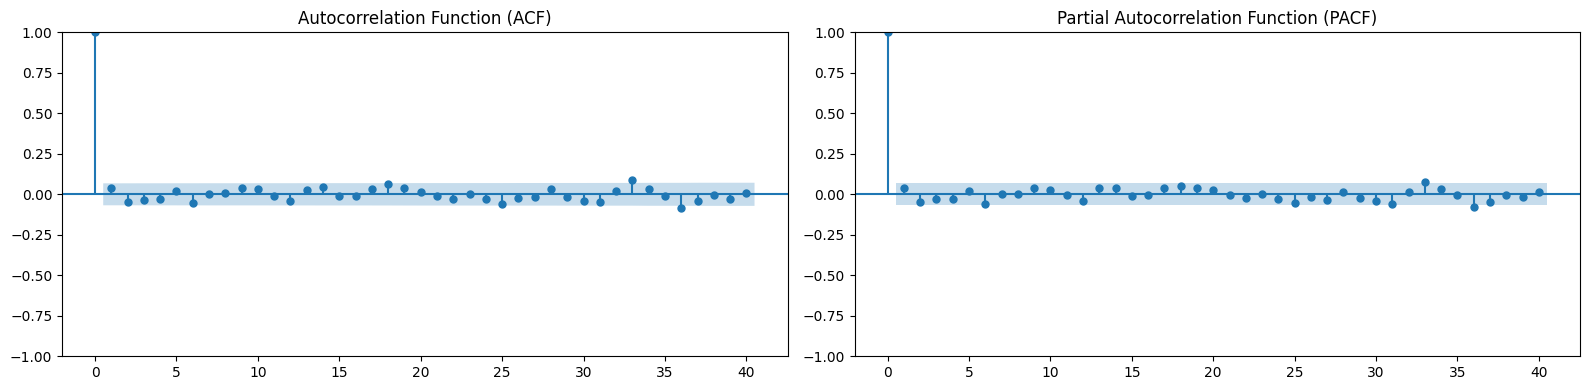


===========Ticker: NVDA===========


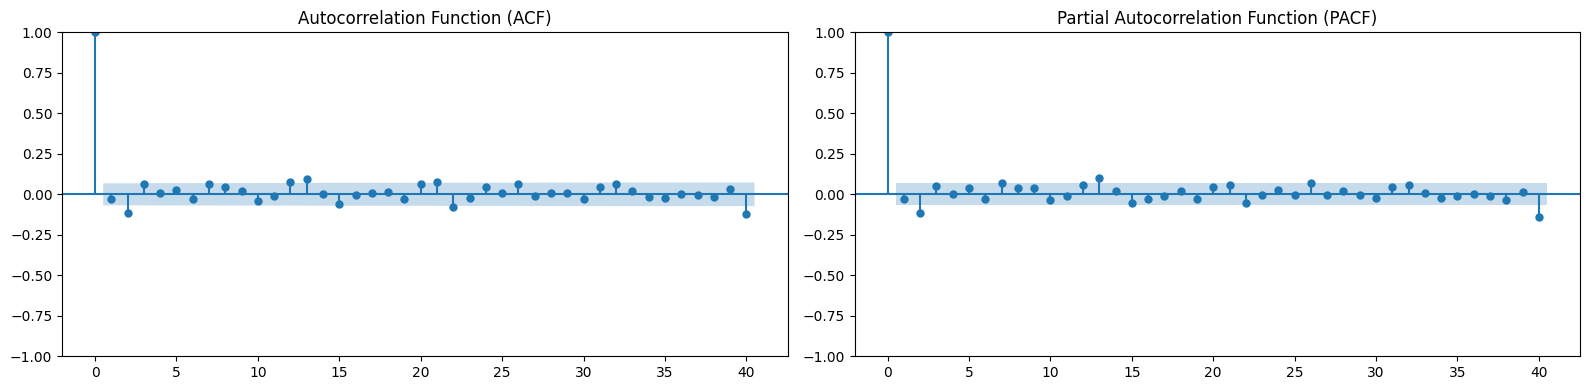


===========Ticker: OXY===========


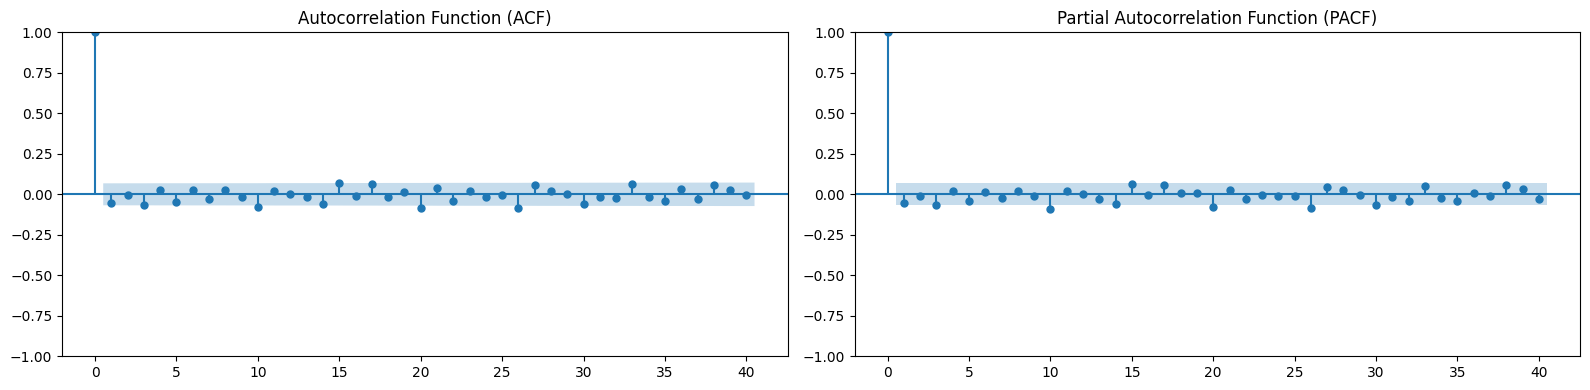


===========Ticker: PARA===========


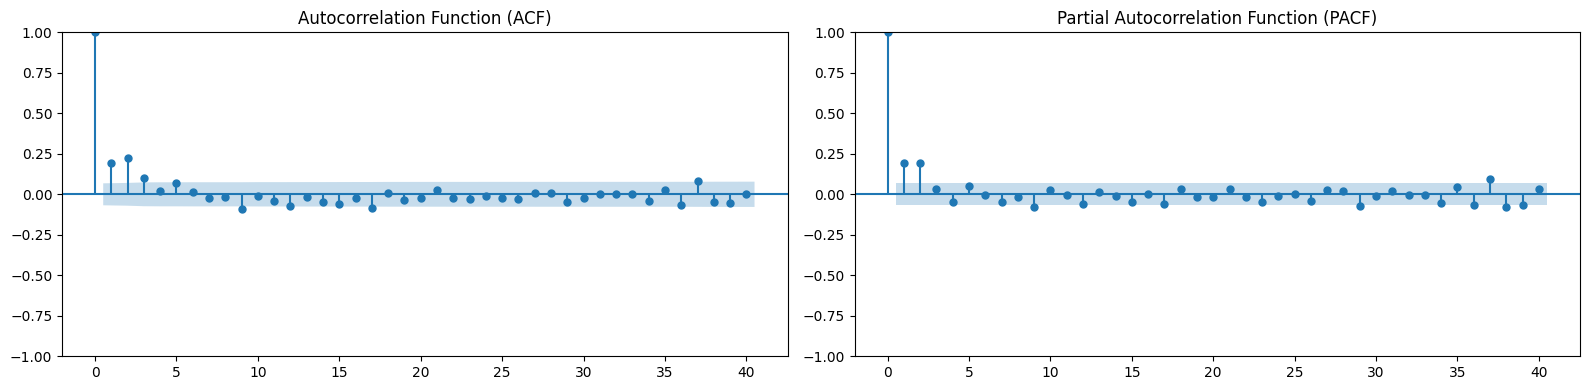


===========Ticker: PPG===========


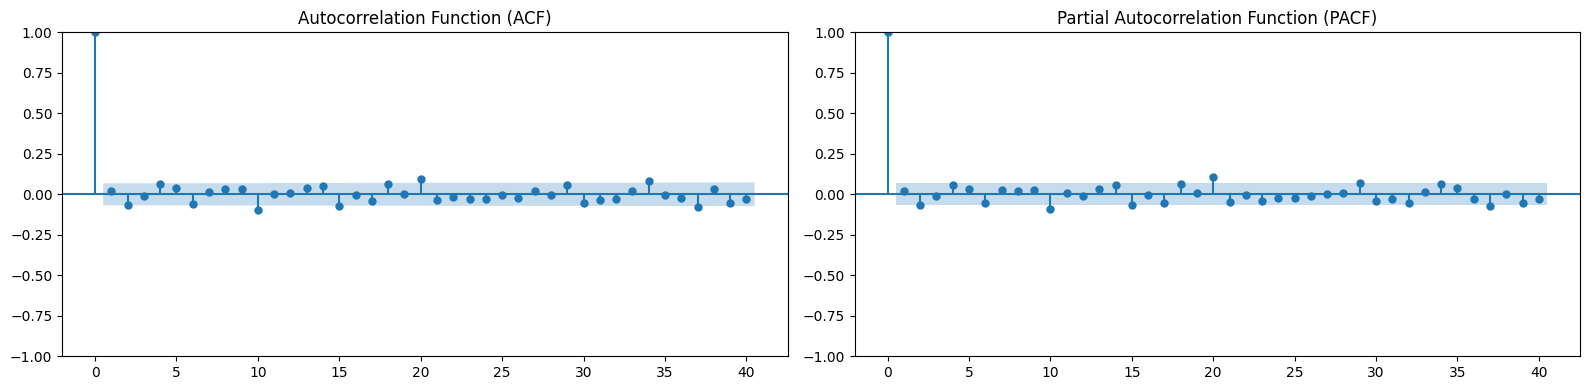


===========Ticker: ROST===========


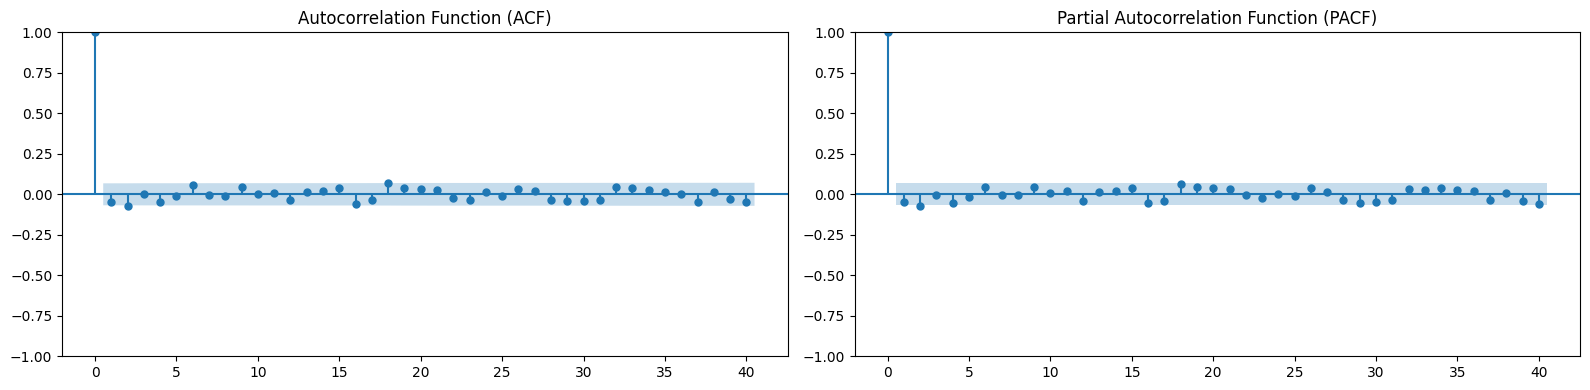


===========Ticker: SPGI===========


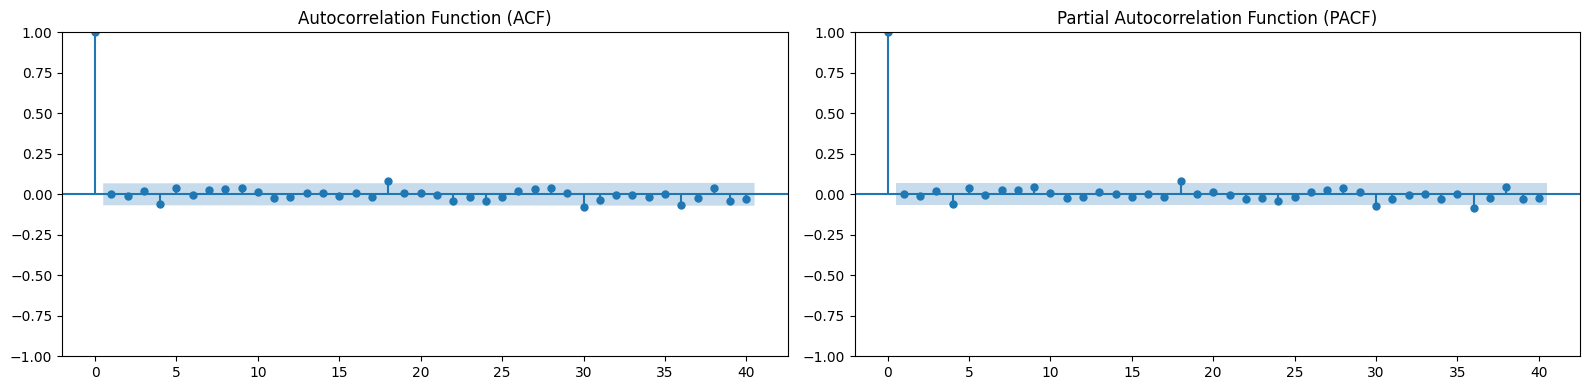


===========Ticker: SYK===========


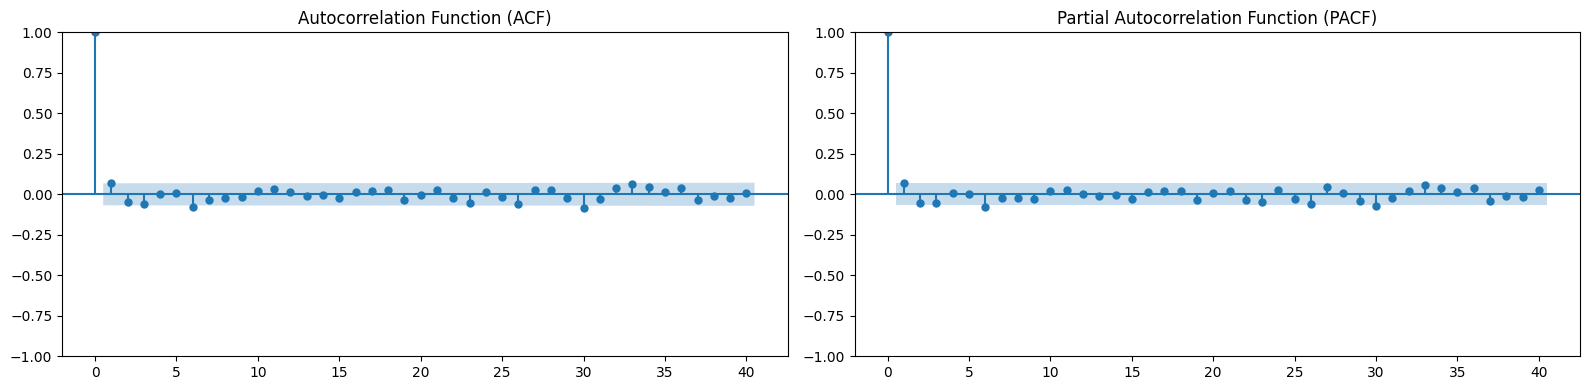


===========Ticker: SYY===========


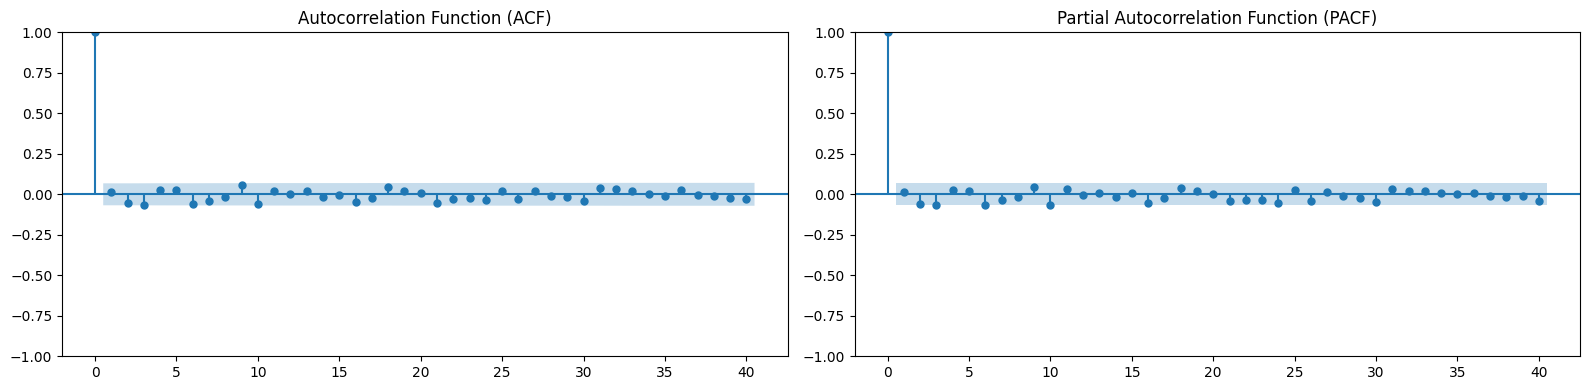


===========Ticker: TGT===========


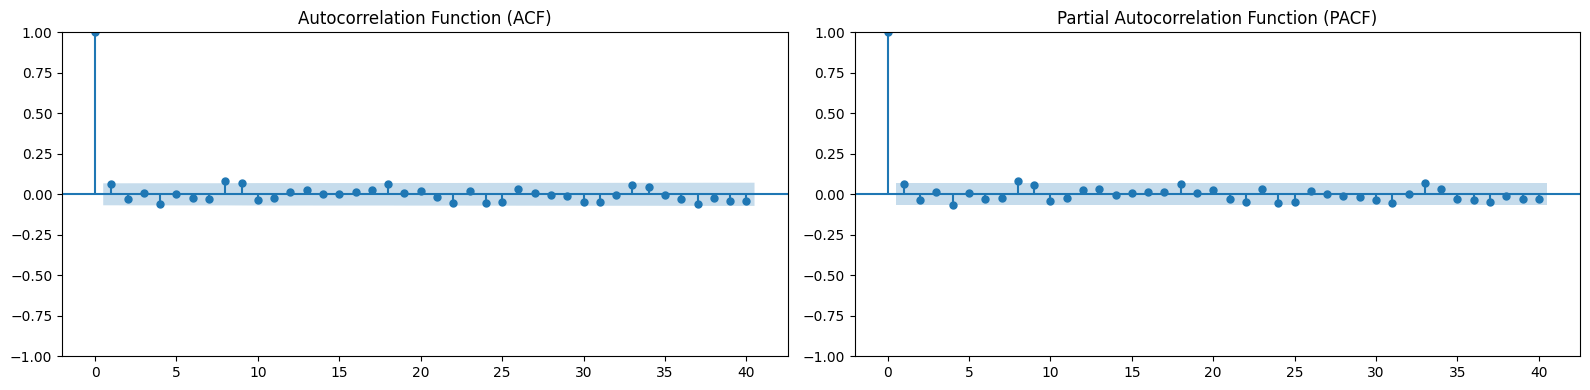


===========Ticker: TPR===========


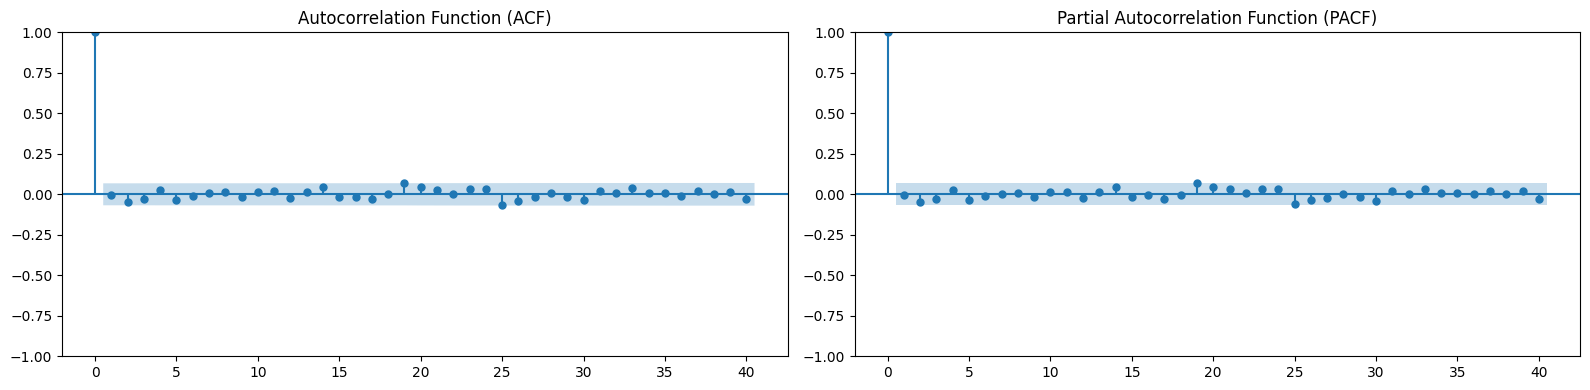


===========Ticker: TSN===========


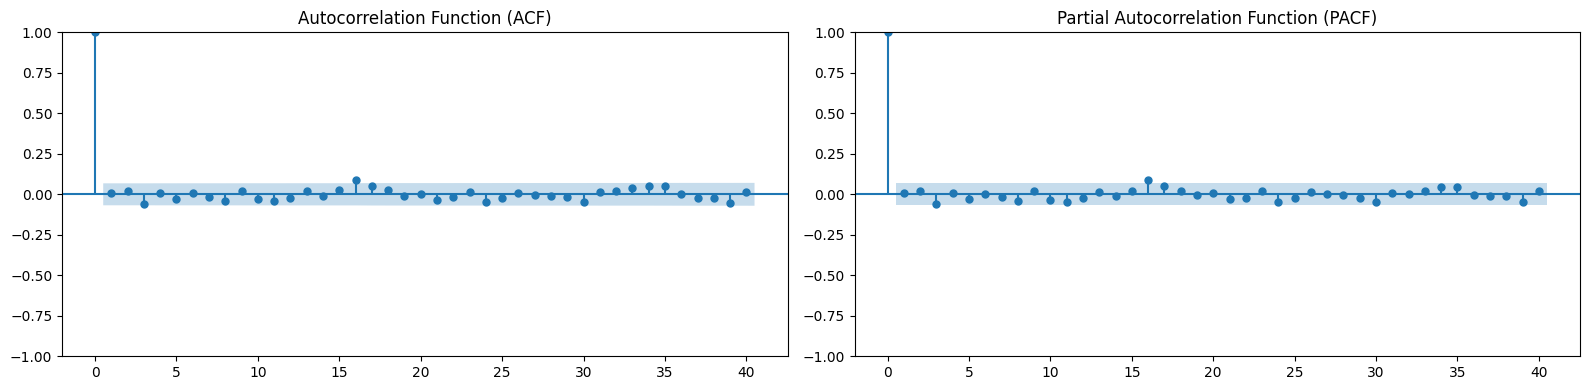


===========Ticker: TXN===========


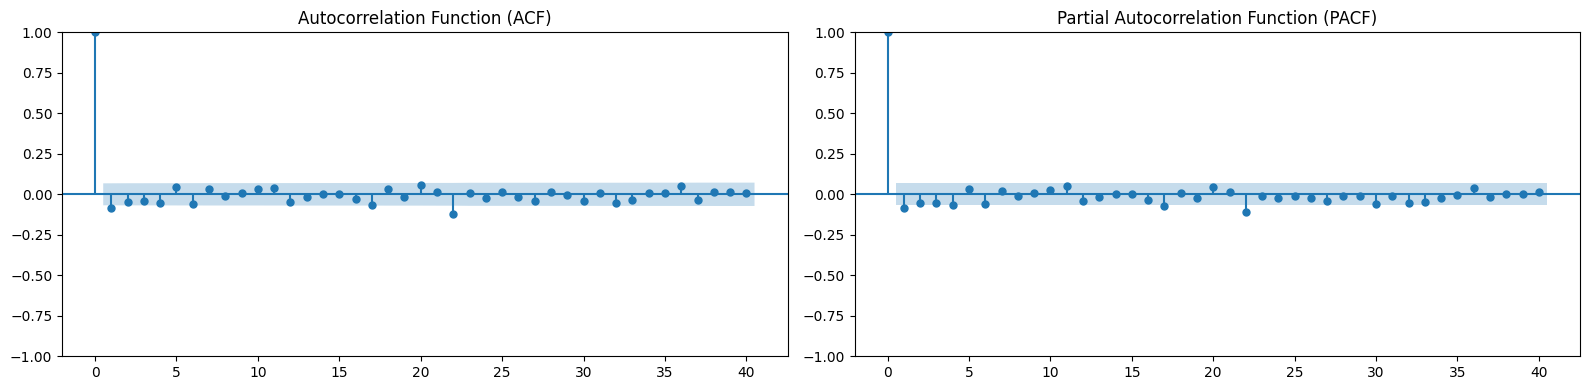


===========Ticker: TXT===========


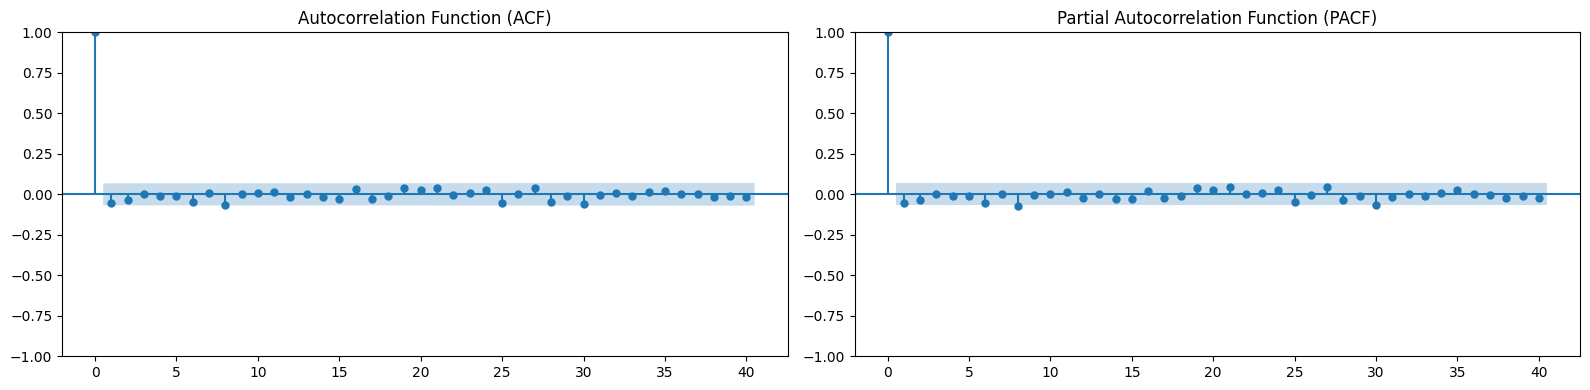


===========Ticker: UNH===========


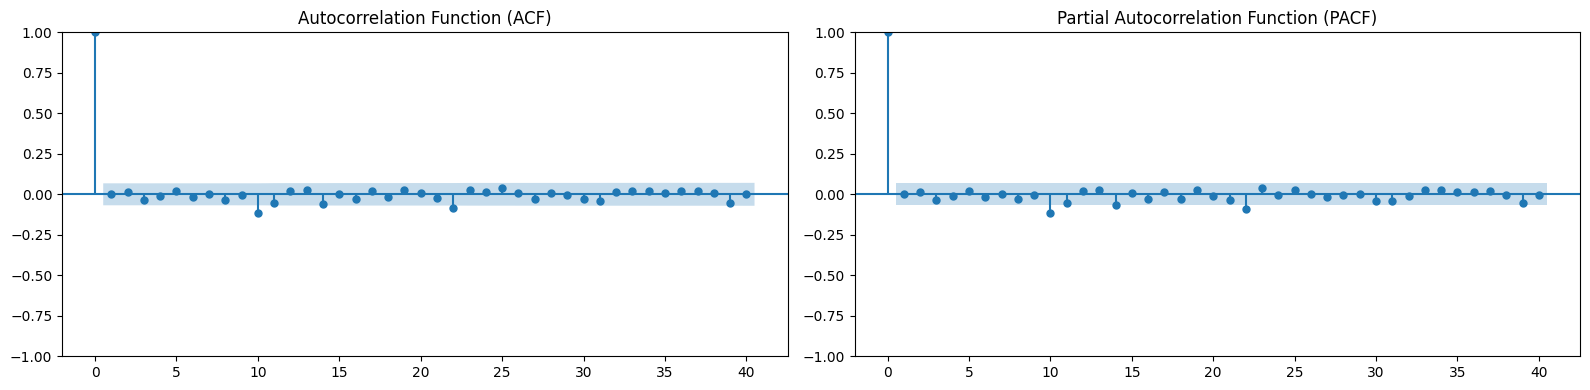


===========Ticker: USB===========


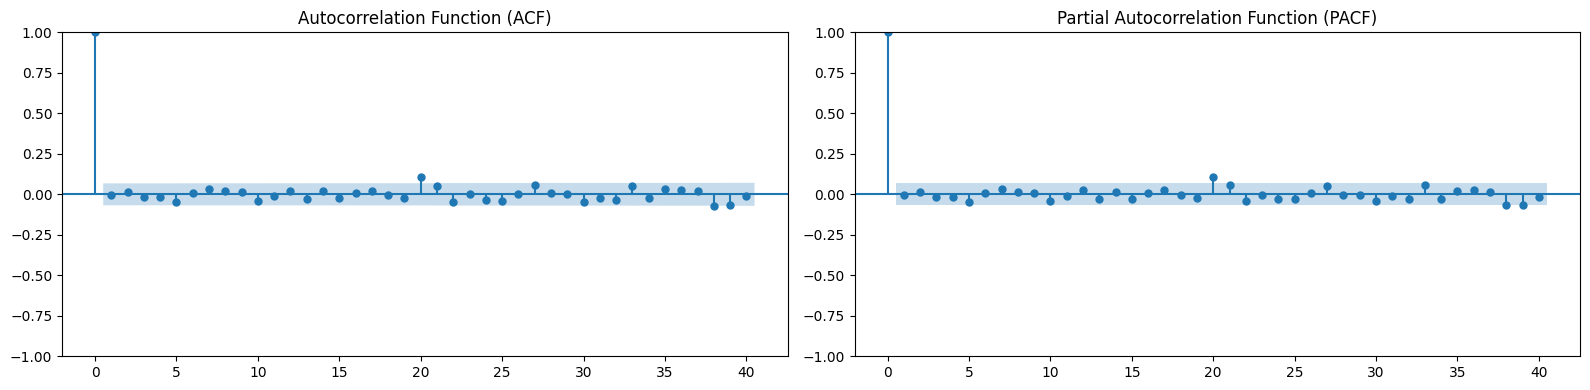


===========Ticker: VLO===========


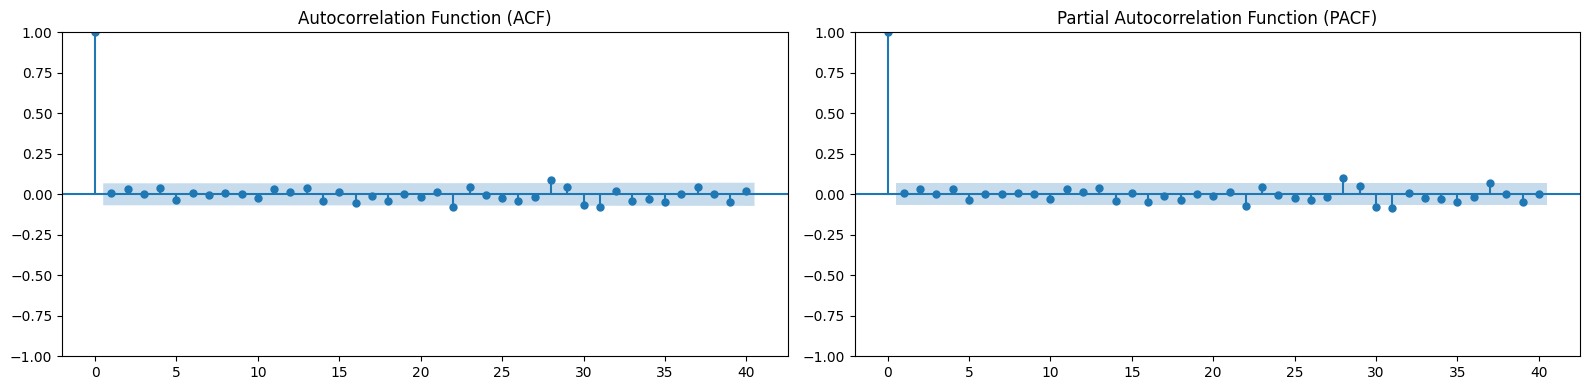


===========Ticker: WEC===========


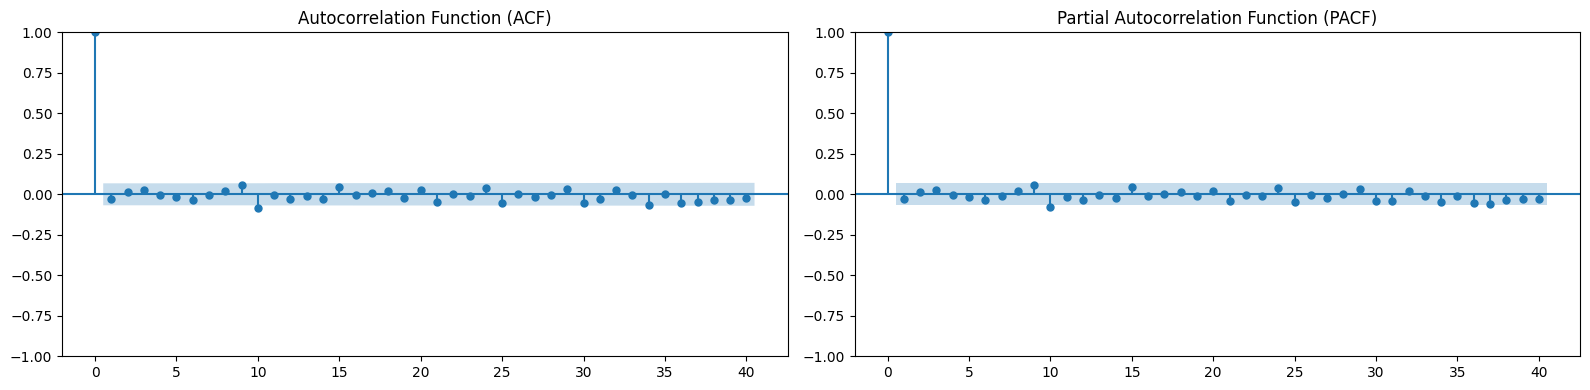


===========Ticker: WELL===========


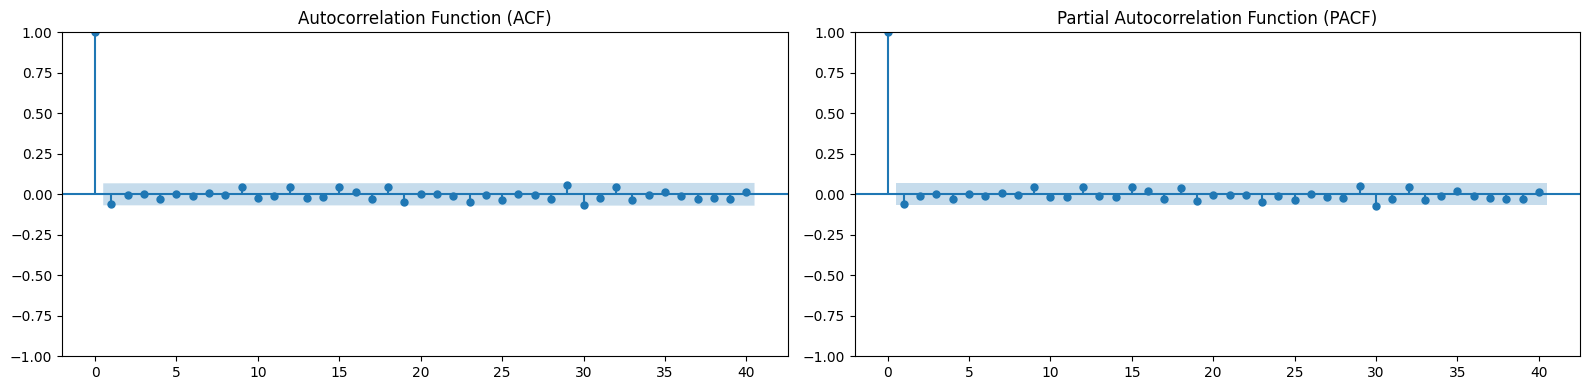


===========Ticker: WY===========


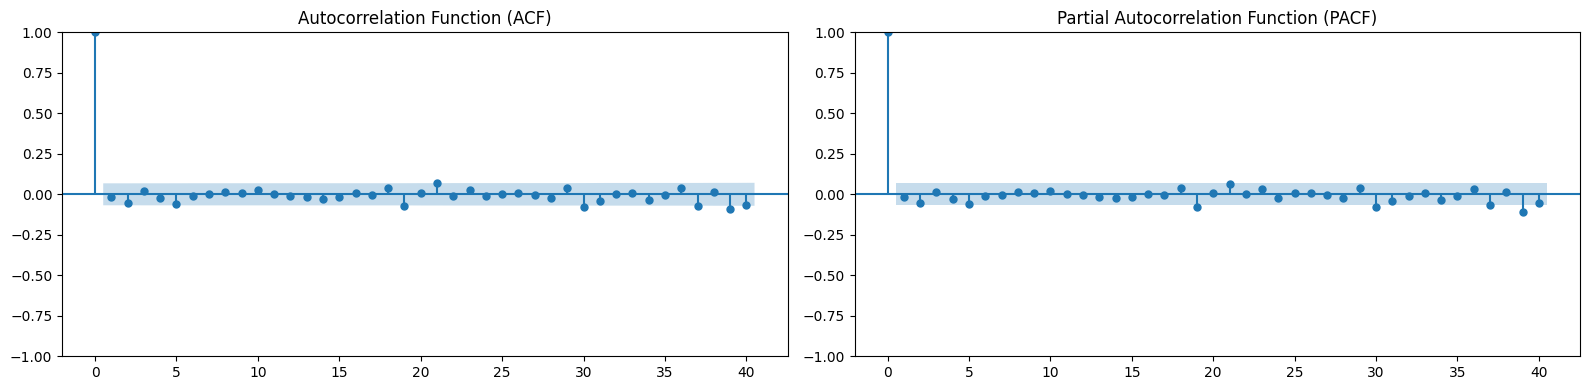

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt


for ticker in train['ticker'].unique():

  print(f"\n===========Ticker: {ticker}===========")

  data = train[train['ticker'] == ticker].copy()
  data = data.sort_values('date')
  data['adjClose_Diff'] = data['adjClose'].diff()

  # Plot ACF and PACF for the differenced series
  fig, axes = plt.subplots(1, 2, figsize=(16, 4))

  # ACF plot
  plot_acf(data['adjClose_Diff'].dropna(), lags=40, ax=axes[0])
  axes[0].set_title('Autocorrelation Function (ACF)')

  # PACF plot
  plot_pacf(data['adjClose_Diff'].dropna(), lags=40, ax=axes[1])
  axes[1].set_title('Partial Autocorrelation Function (PACF)')

  plt.tight_layout()
  plt.show()

In [ ]:
from statsmodels.tsa.stattools import acf, pacf
import pandas as pd

# Replace with your differenced series
series = train[train['ticker'] == 'A']['target']

acf_vals = acf(series, nlags=40)
pacf_vals = pacf(series, nlags=40)

lags = list(range(41))
df = pd.DataFrame({
    'lag': lags,
    'acf': acf_vals,
    'pacf': pacf_vals
})

df.to_csv('acf_pacf_data.csv', index=False)



===========Ticker: A===========


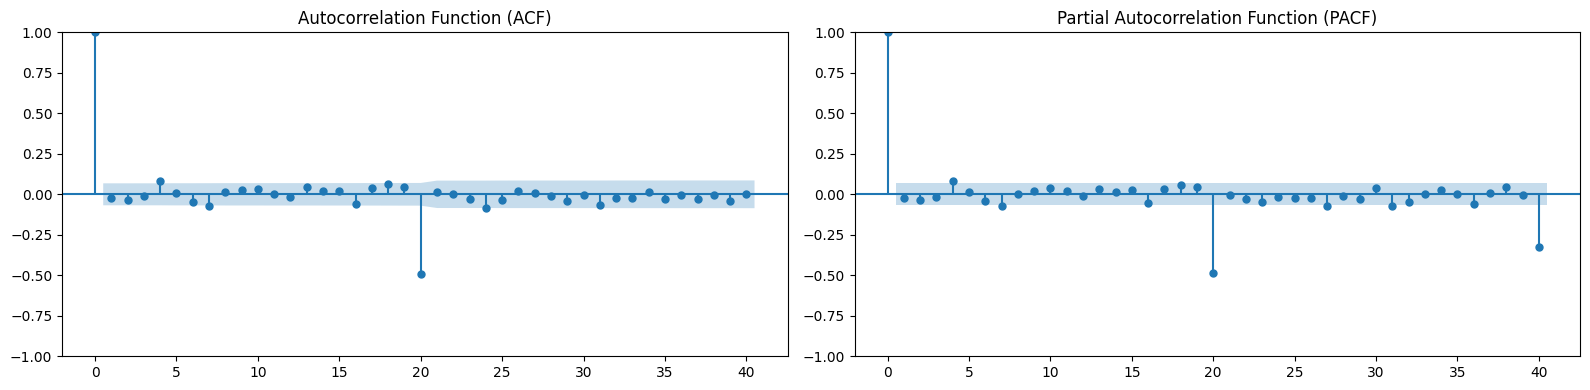


===========Ticker: ABT===========


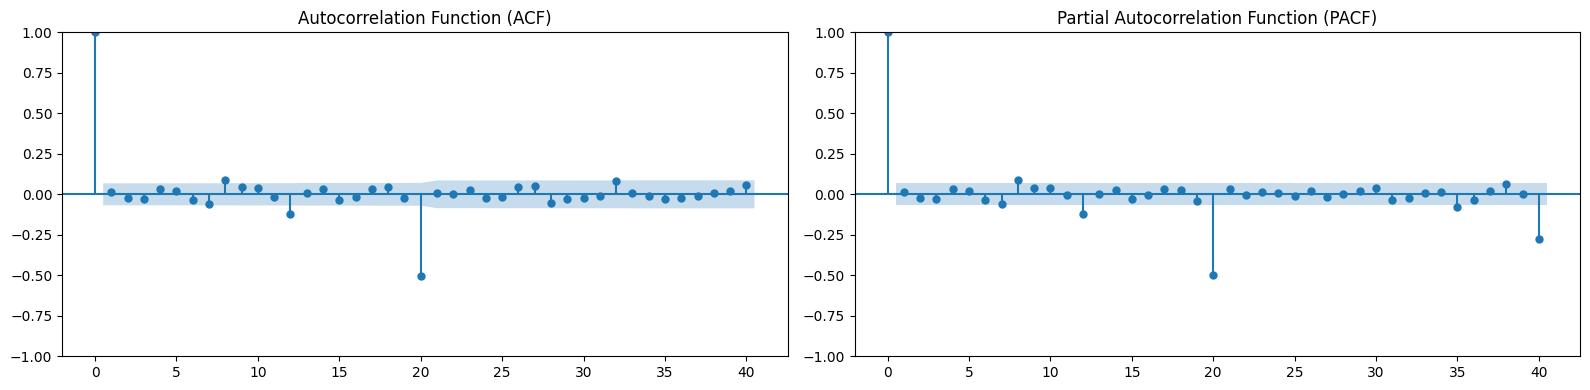


===========Ticker: ADM===========


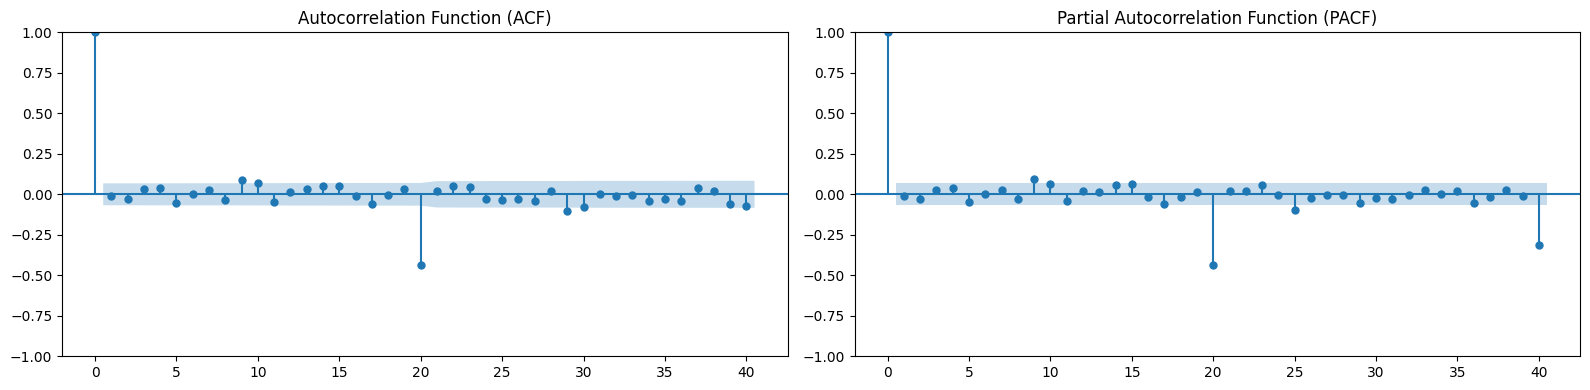


===========Ticker: AES===========


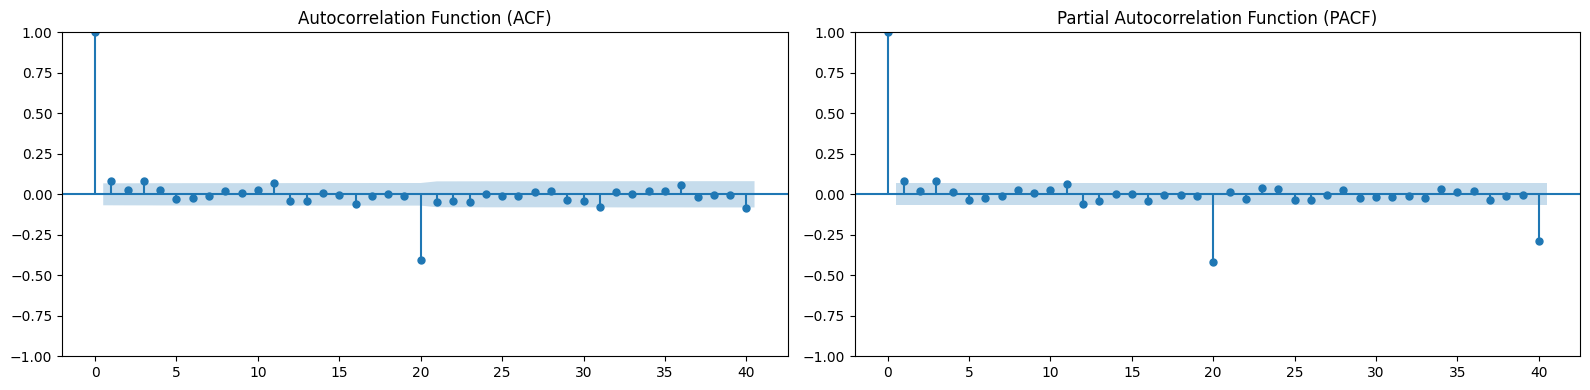


===========Ticker: AMZN===========


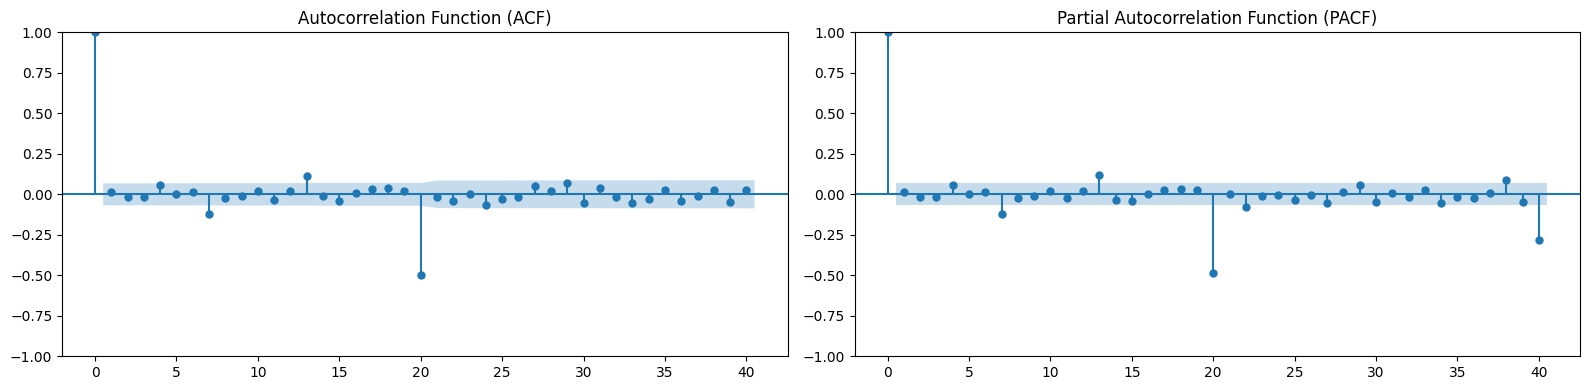


===========Ticker: APA===========


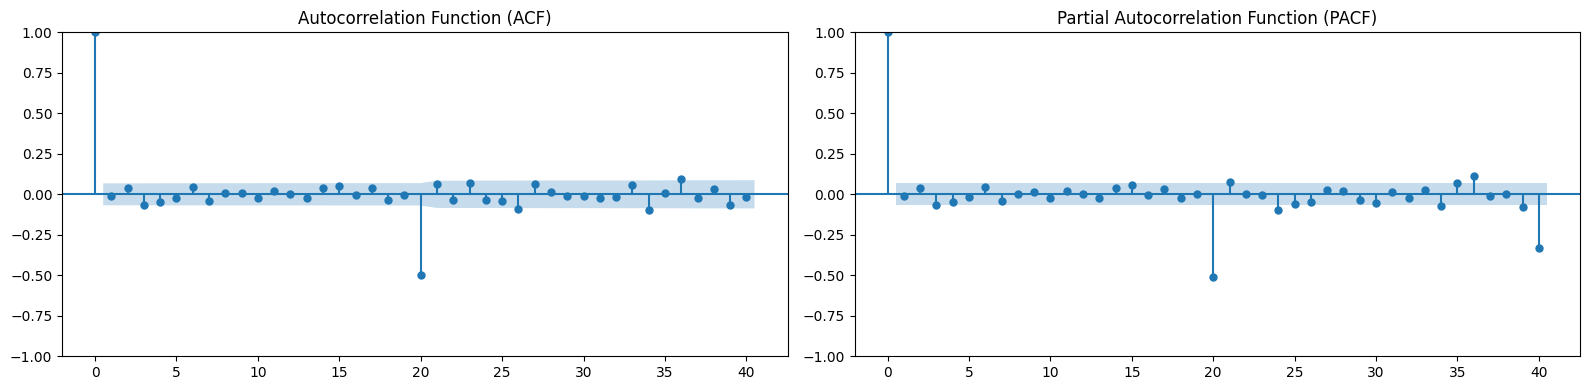


===========Ticker: APD===========


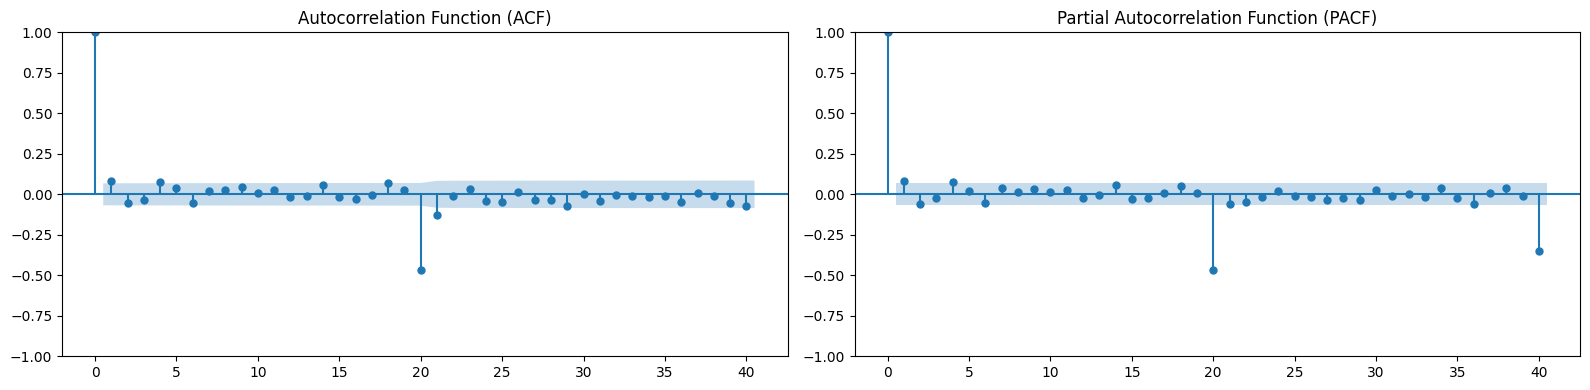


===========Ticker: BA===========


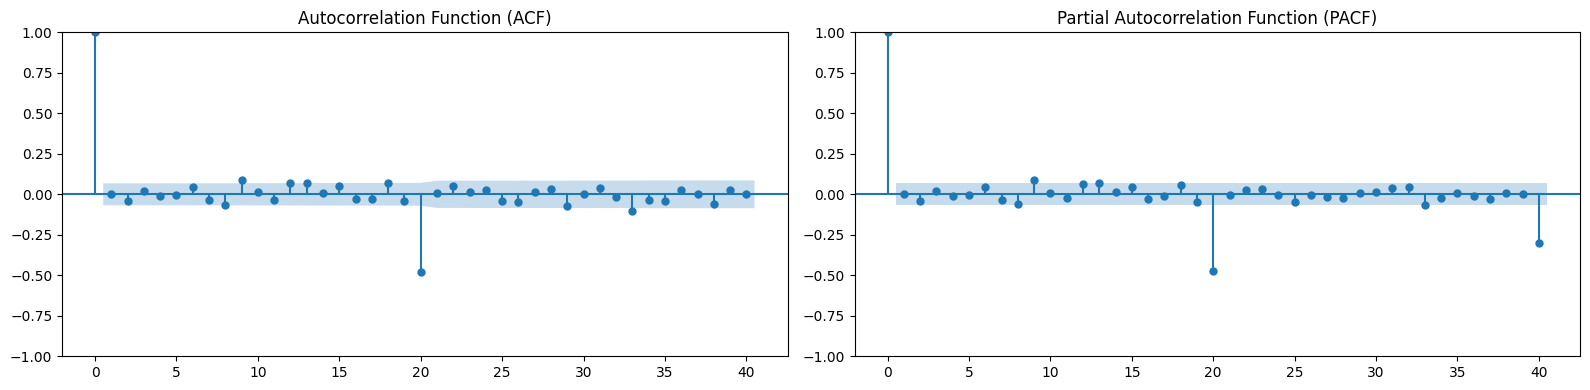


===========Ticker: BAC===========


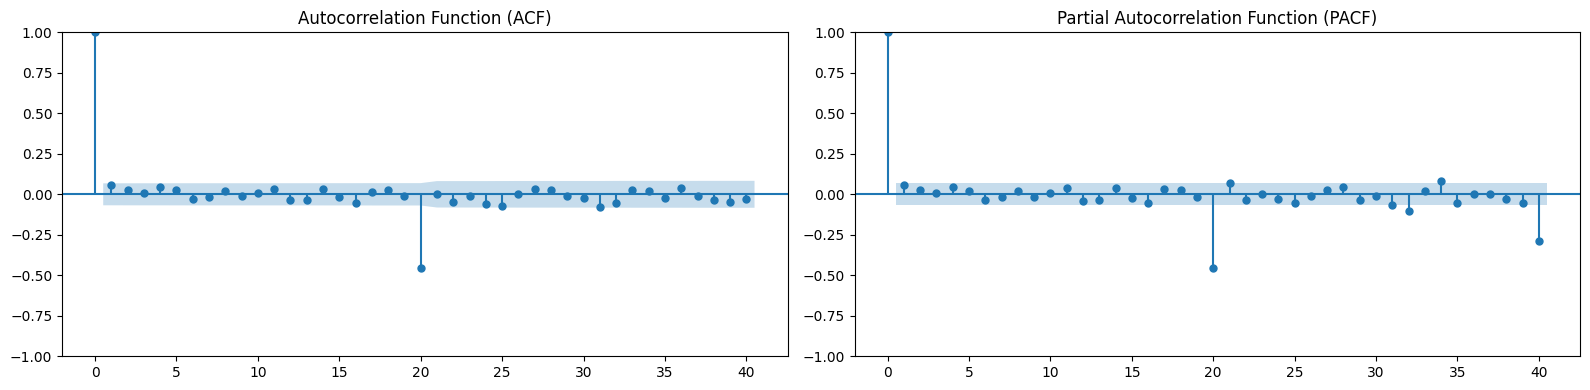


===========Ticker: BALL===========


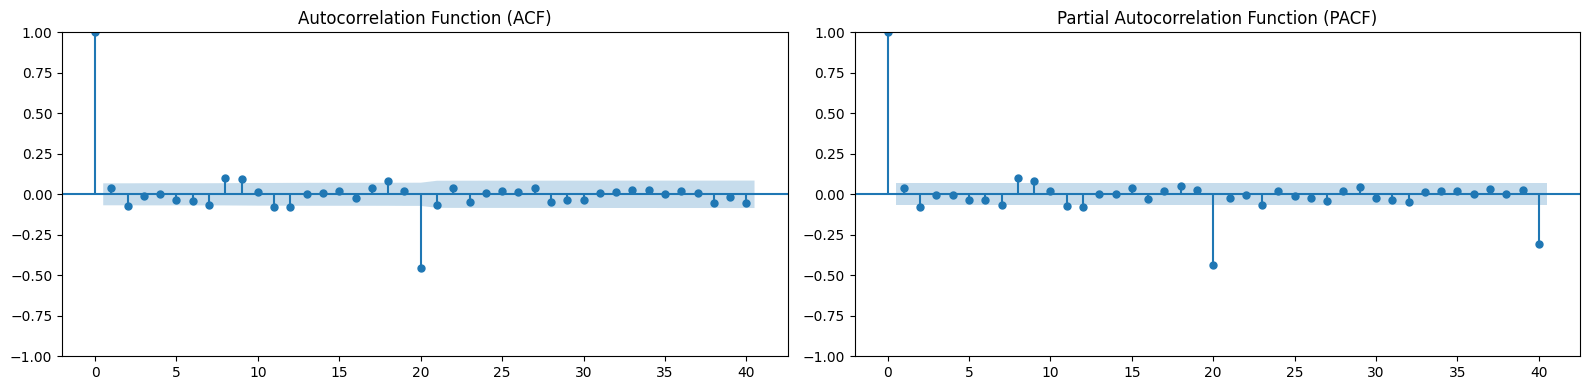


===========Ticker: BBY===========


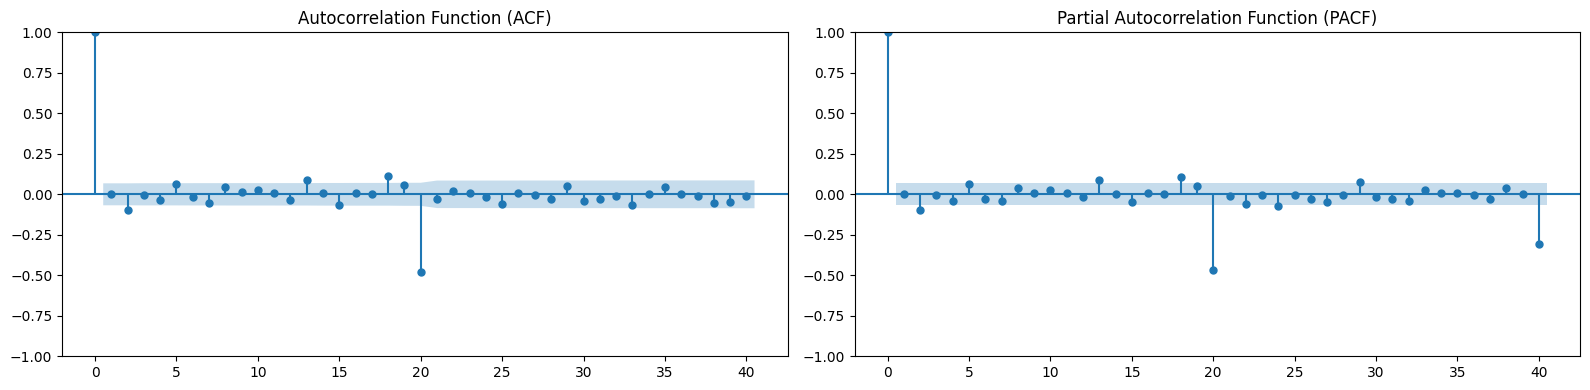


===========Ticker: CBRE===========


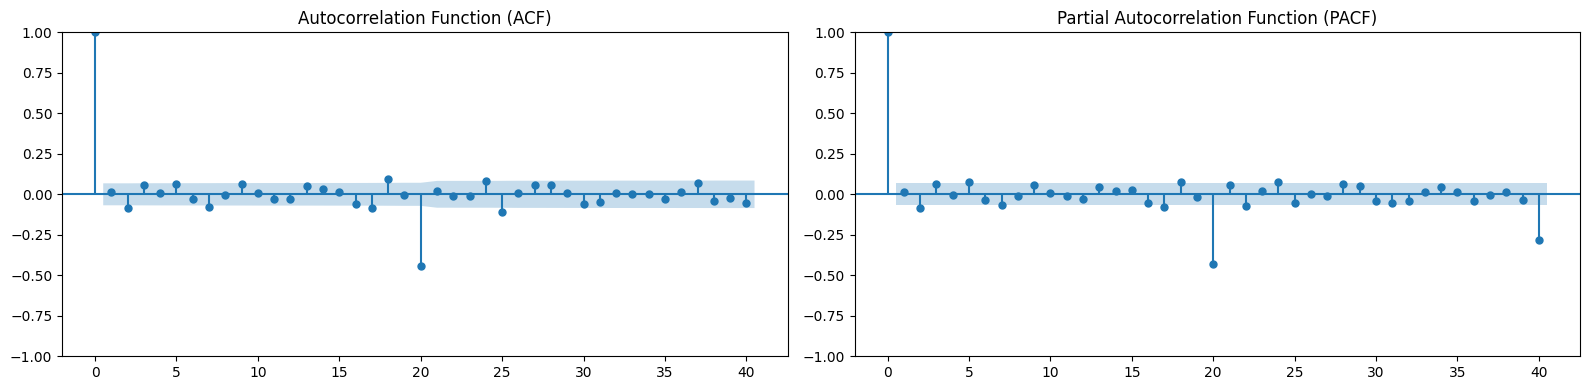


===========Ticker: CMCSA===========


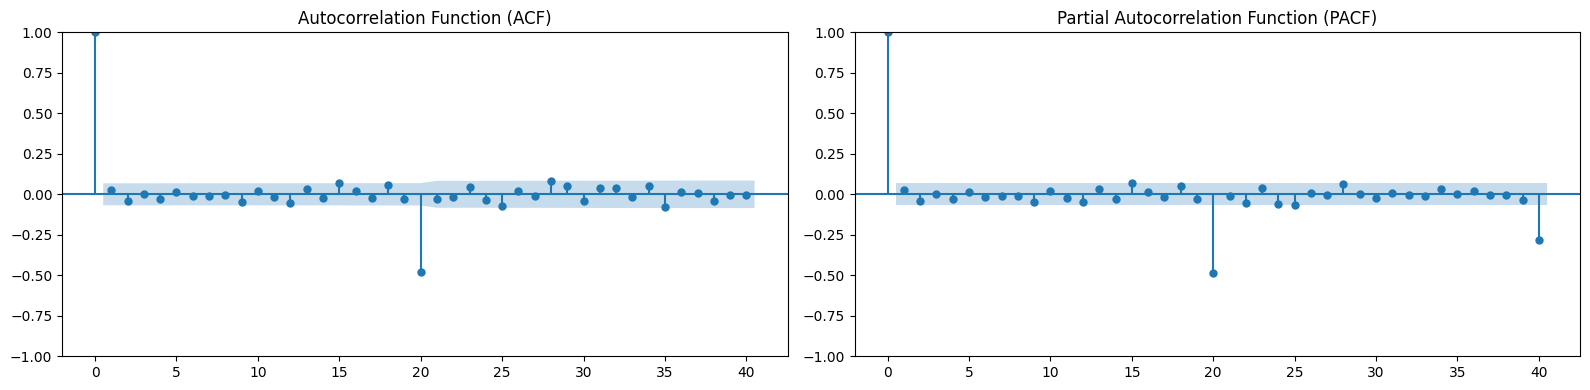


===========Ticker: CNP===========


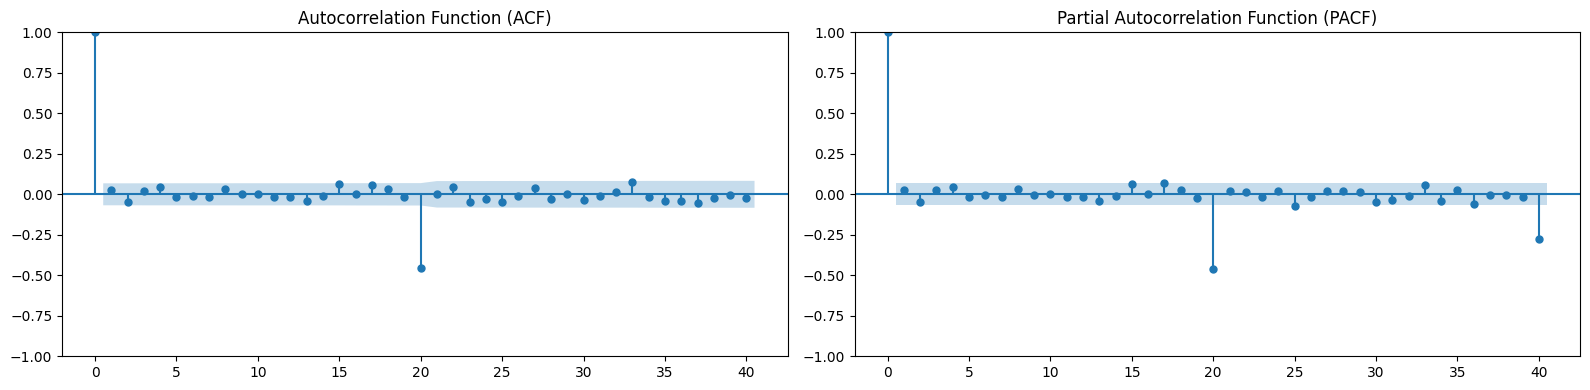


===========Ticker: CTSH===========


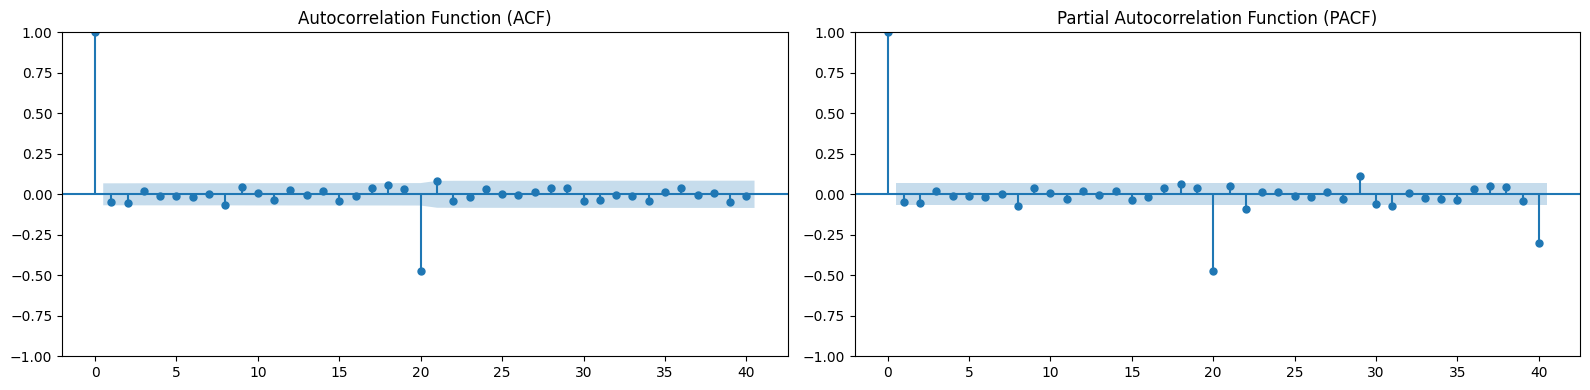


===========Ticker: EA===========


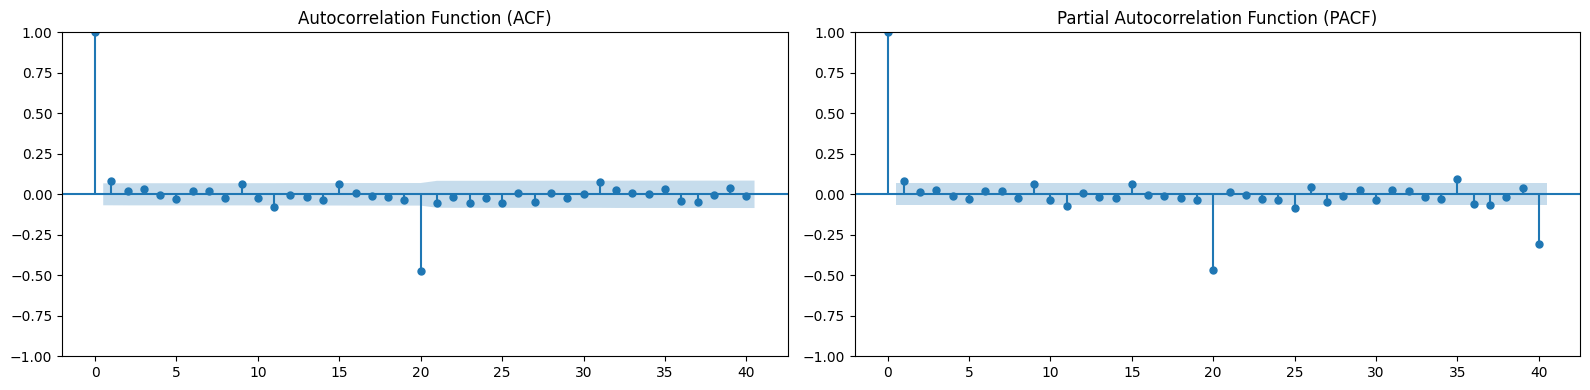


===========Ticker: EMR===========


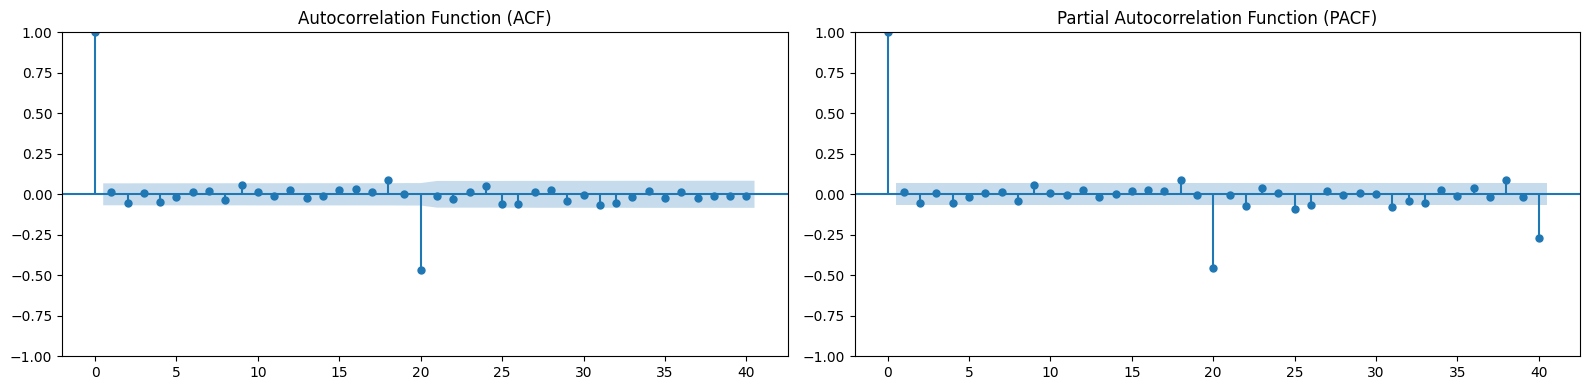


===========Ticker: FI===========


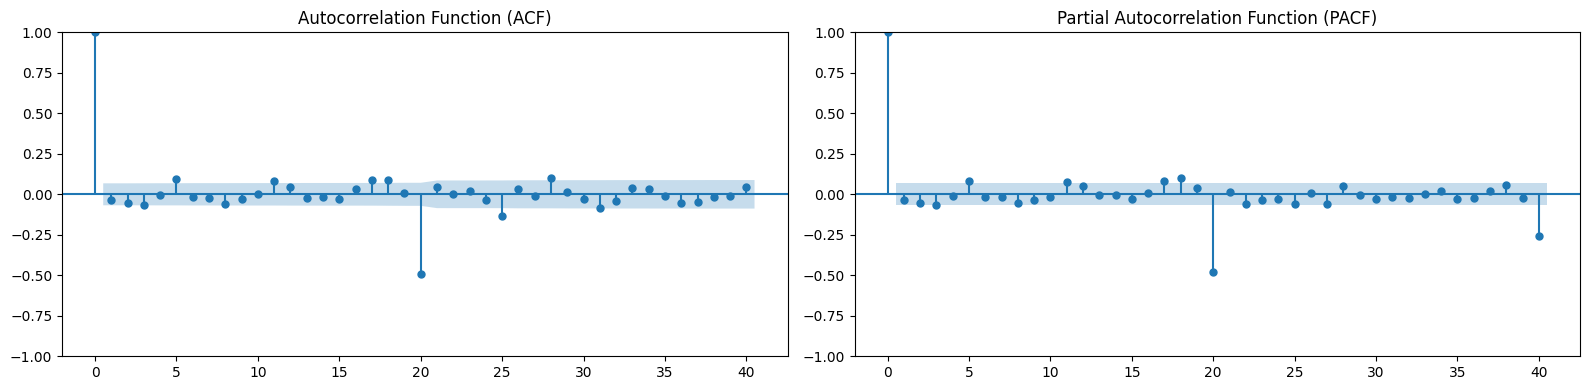


===========Ticker: GLW===========


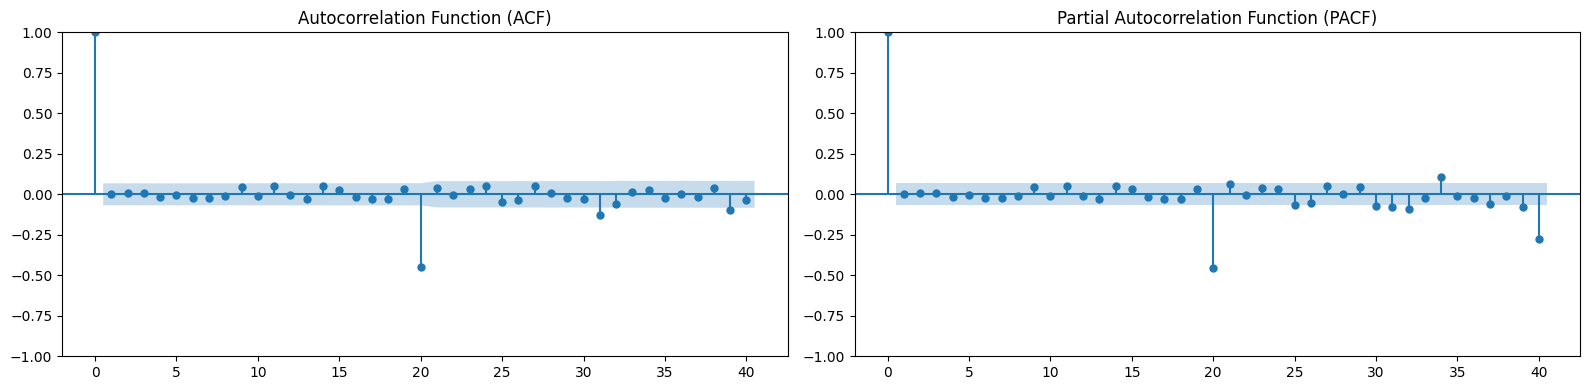


===========Ticker: GOOG===========


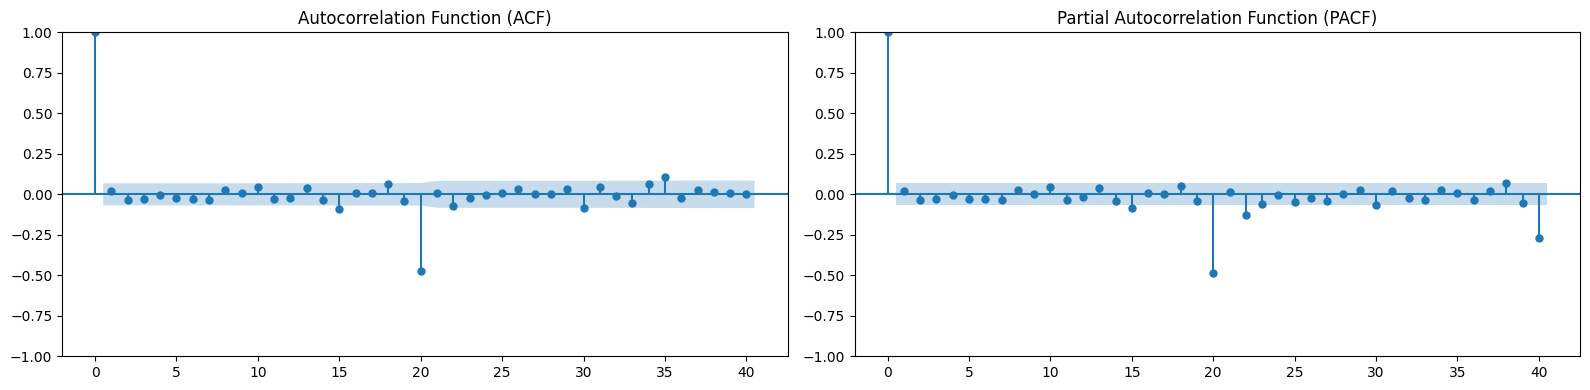


===========Ticker: HES===========


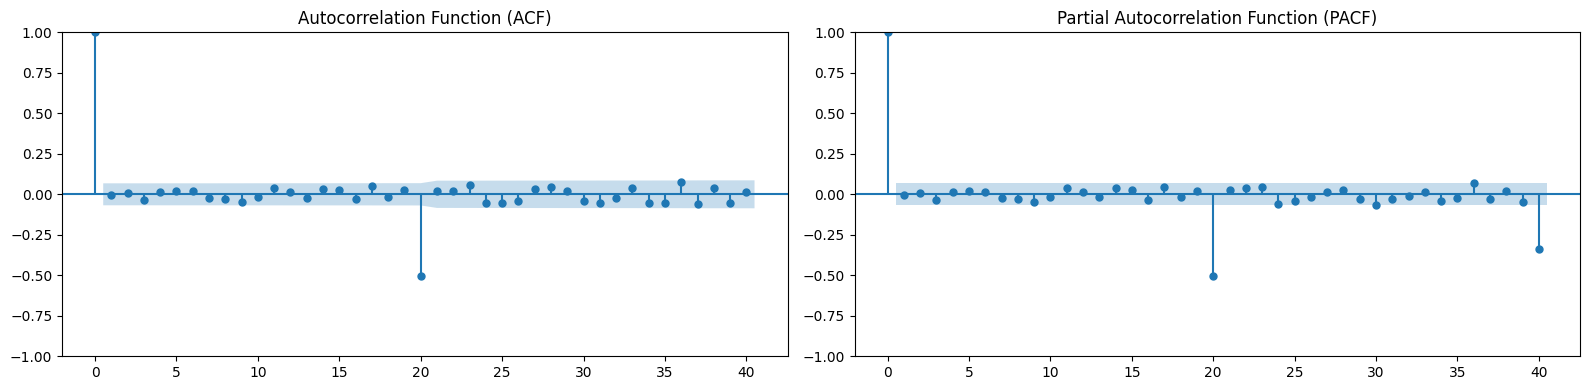


===========Ticker: KIM===========


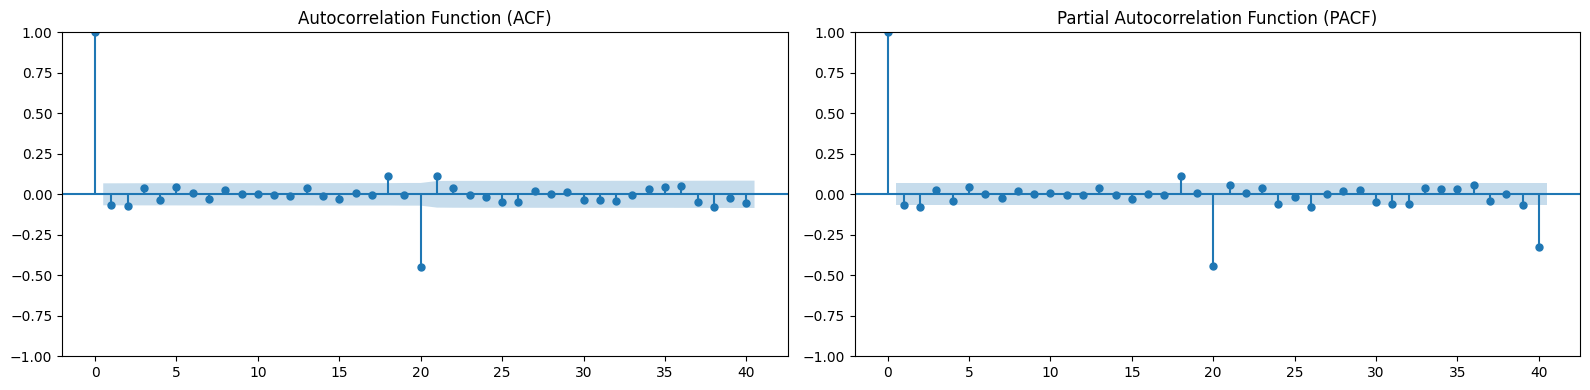


===========Ticker: NEE===========


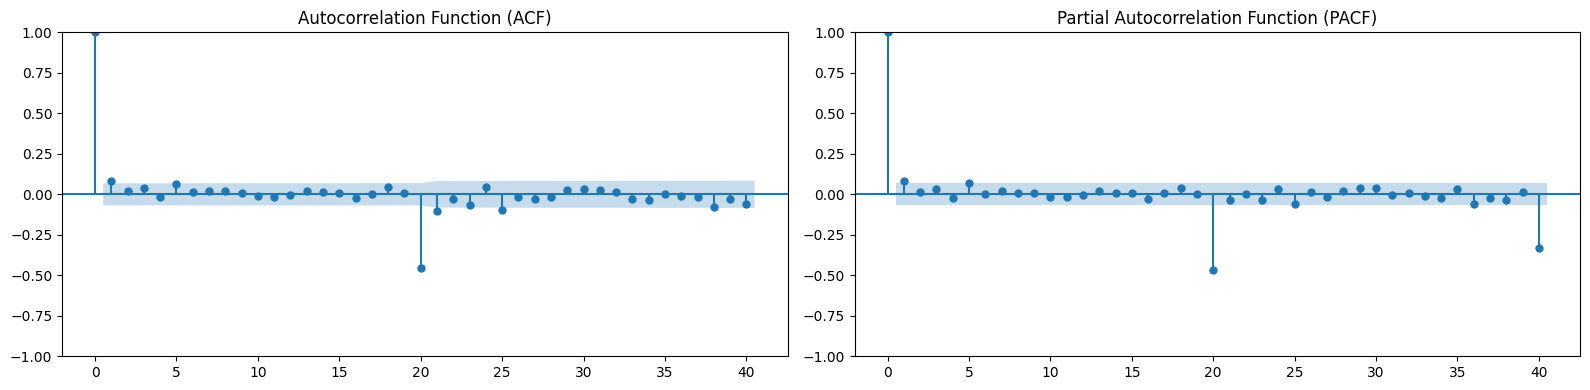


===========Ticker: NEM===========


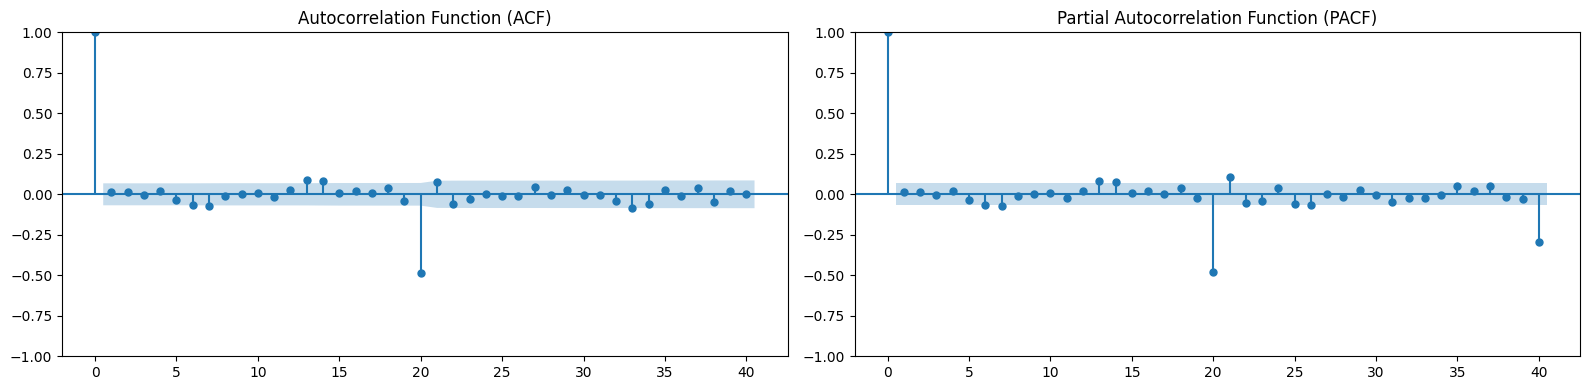


===========Ticker: NSC===========


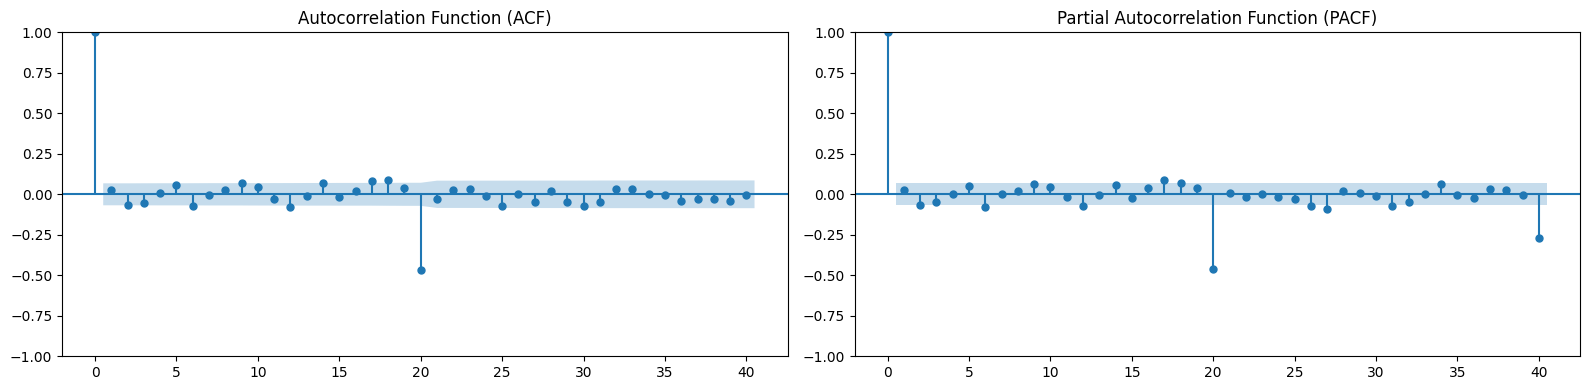


===========Ticker: NVDA===========


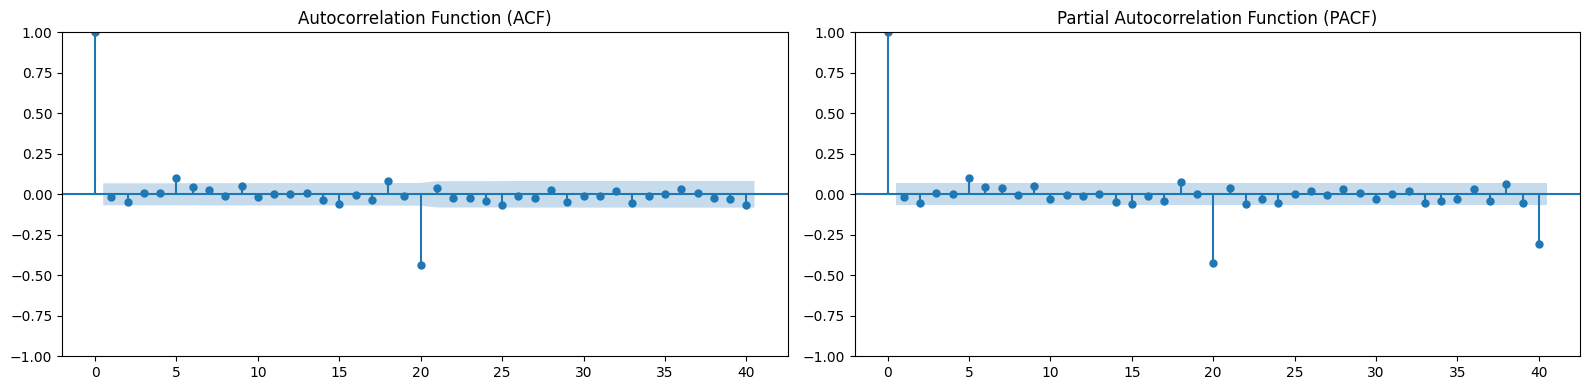


===========Ticker: OXY===========


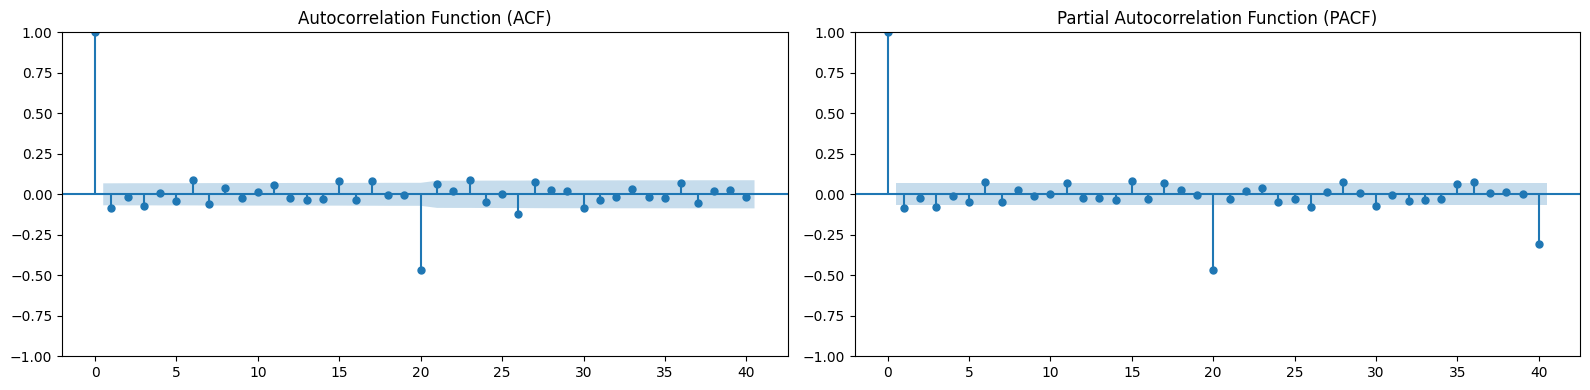


===========Ticker: PARA===========


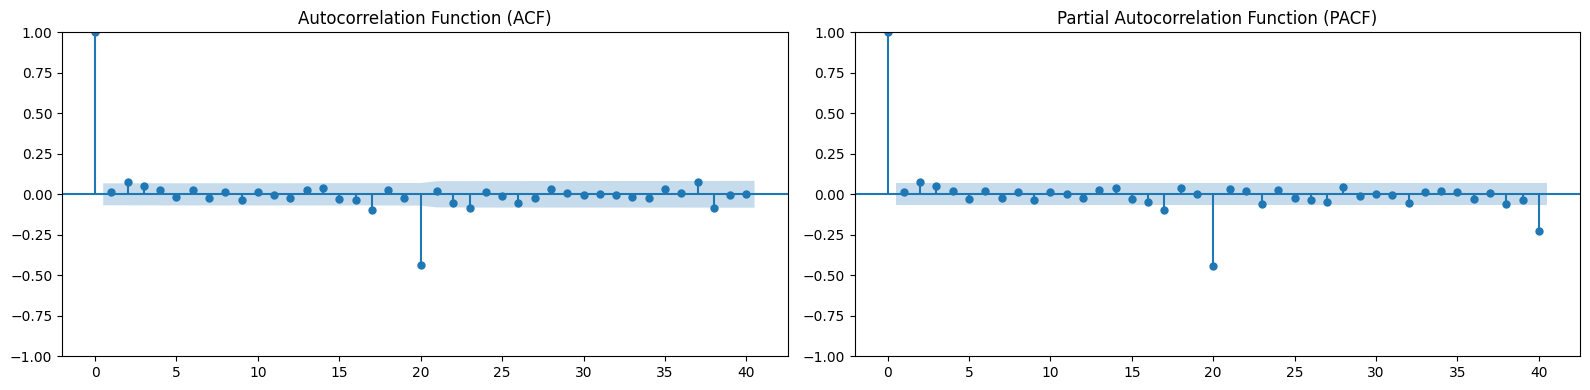


===========Ticker: PPG===========


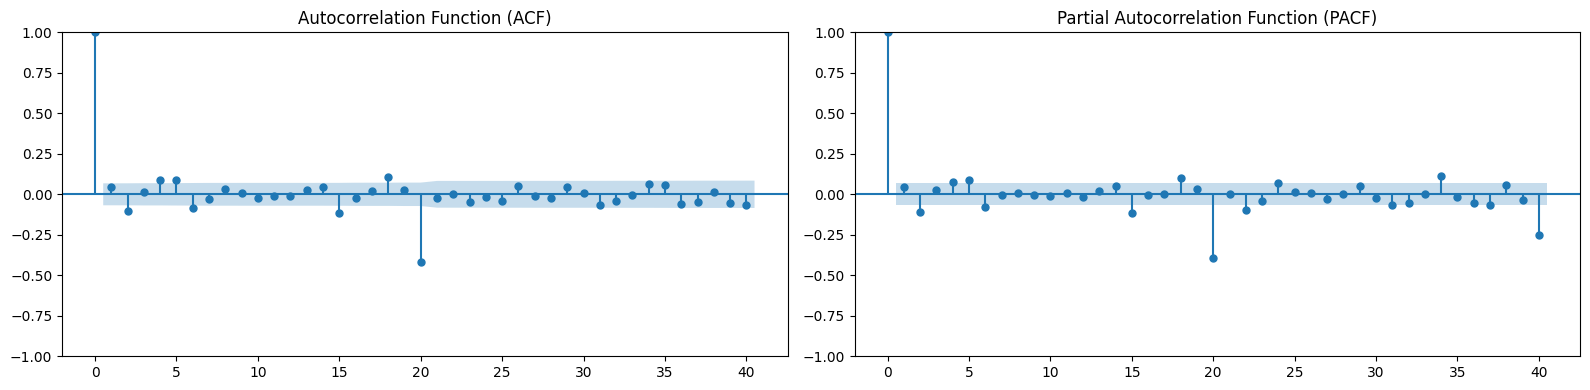


===========Ticker: ROST===========


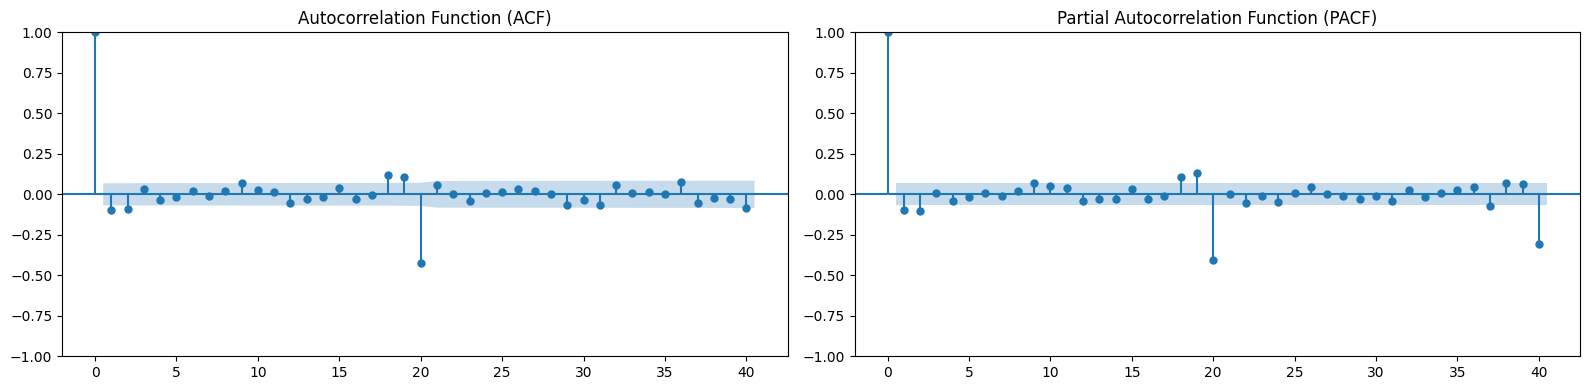


===========Ticker: SPGI===========


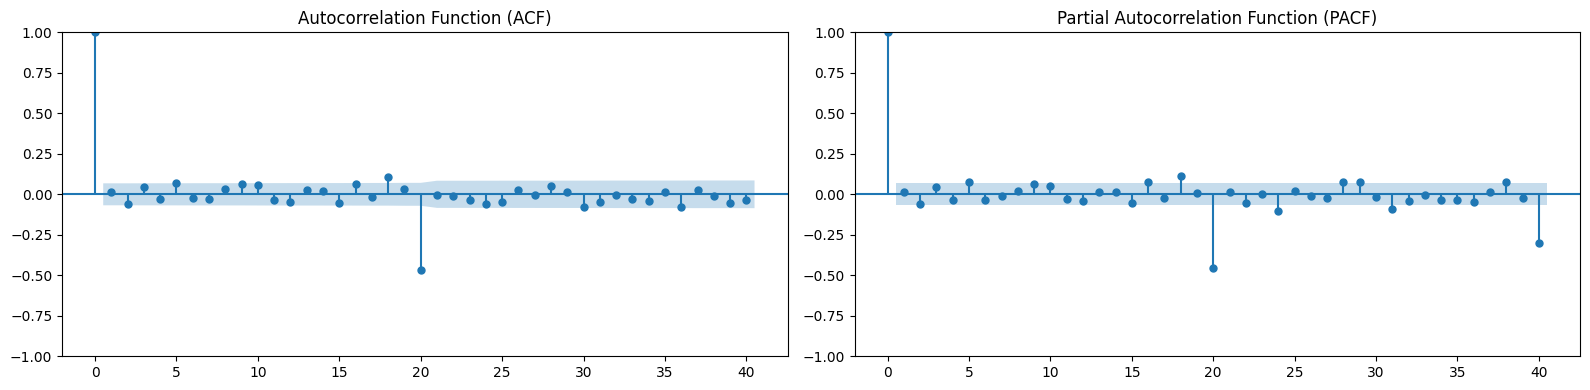


===========Ticker: SYK===========


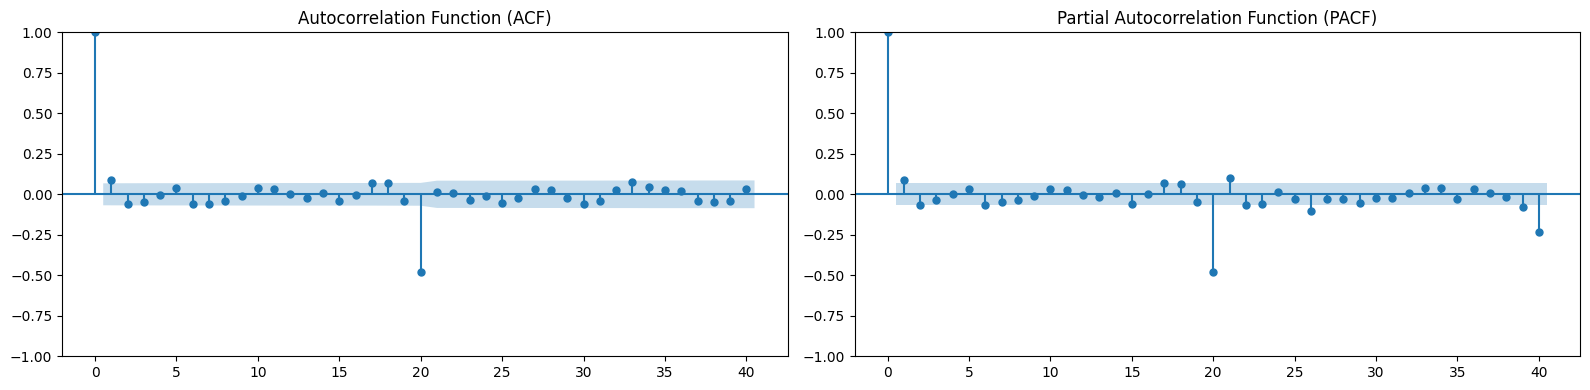


===========Ticker: SYY===========


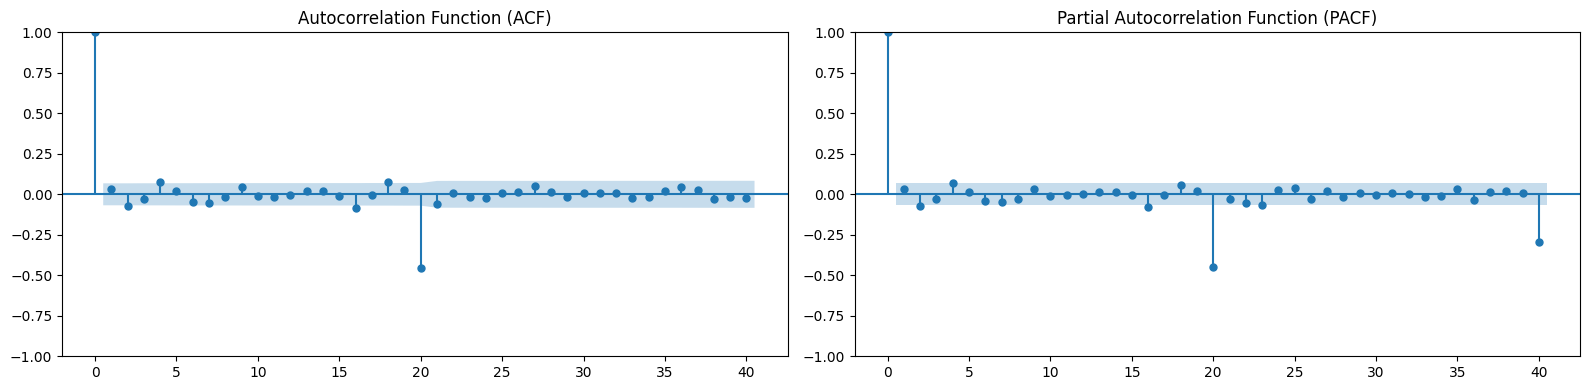


===========Ticker: TGT===========


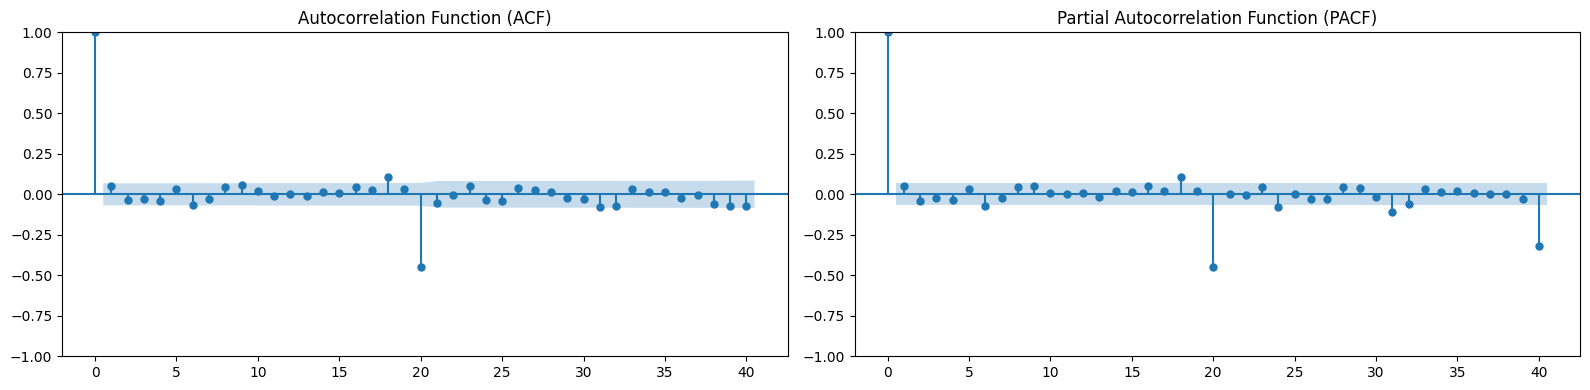


===========Ticker: TPR===========


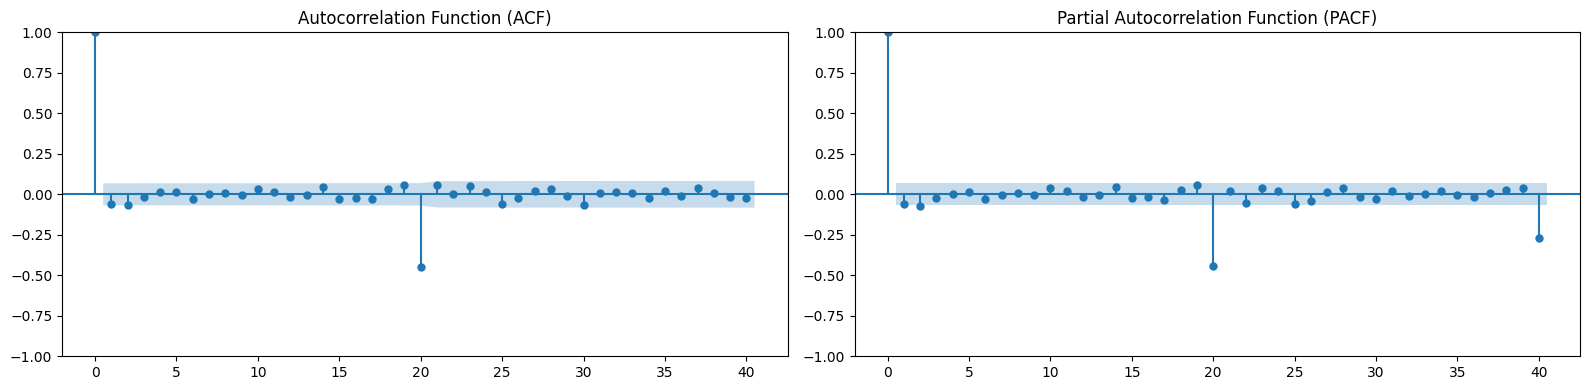


===========Ticker: TSN===========


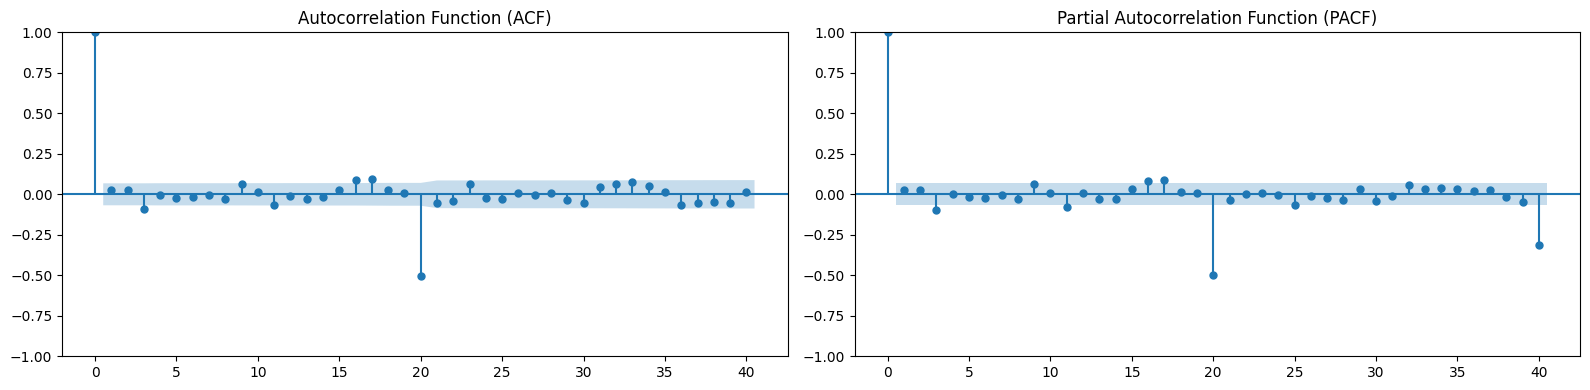


===========Ticker: TXN===========


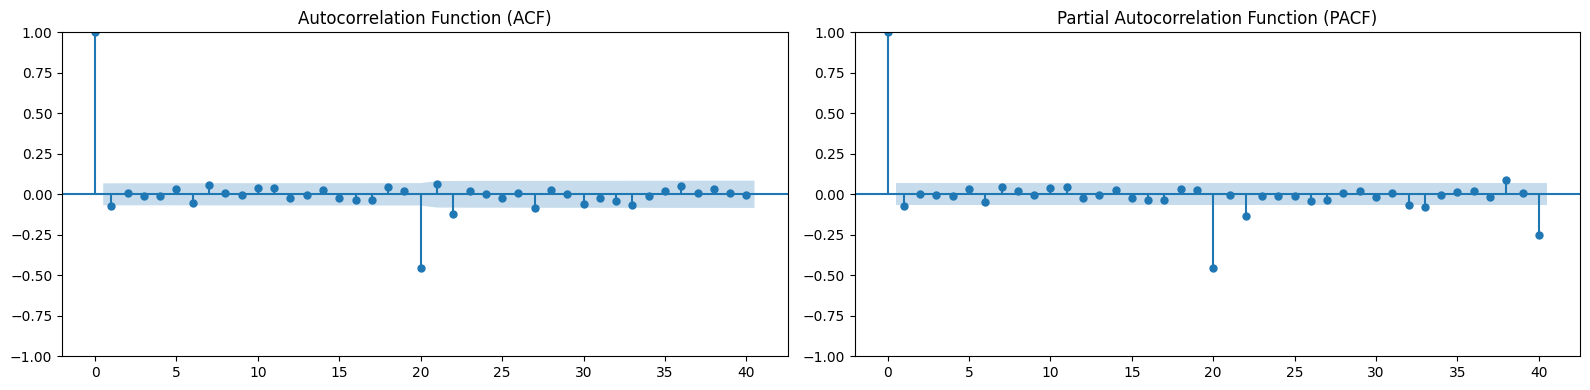


===========Ticker: TXT===========


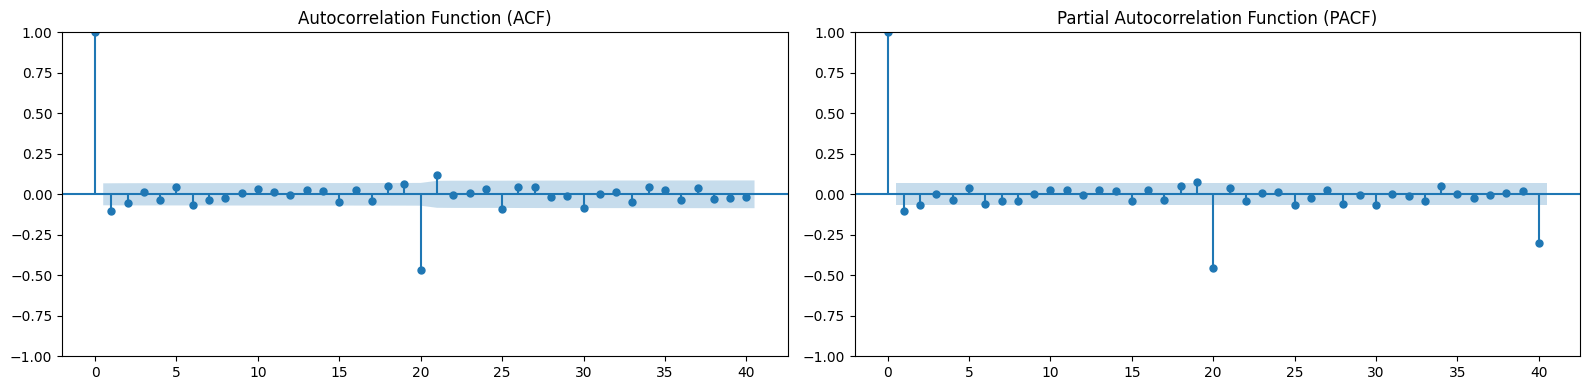


===========Ticker: UNH===========


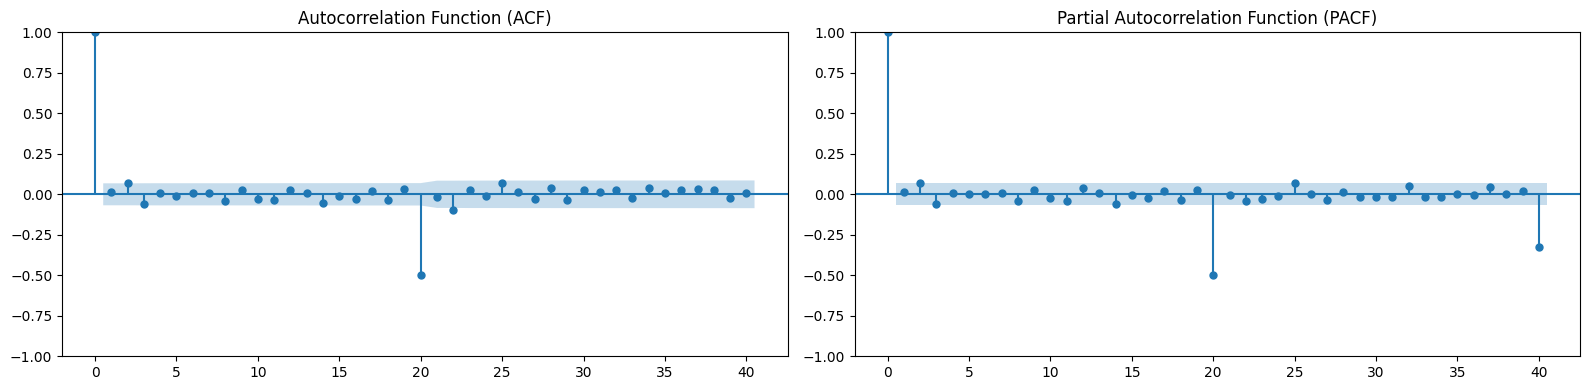


===========Ticker: USB===========


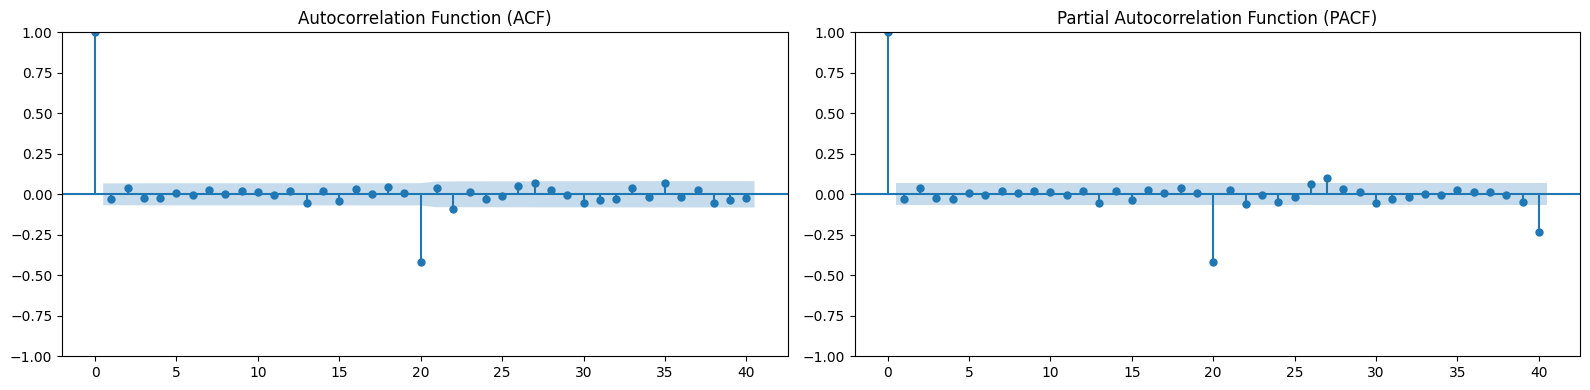


===========Ticker: VLO===========


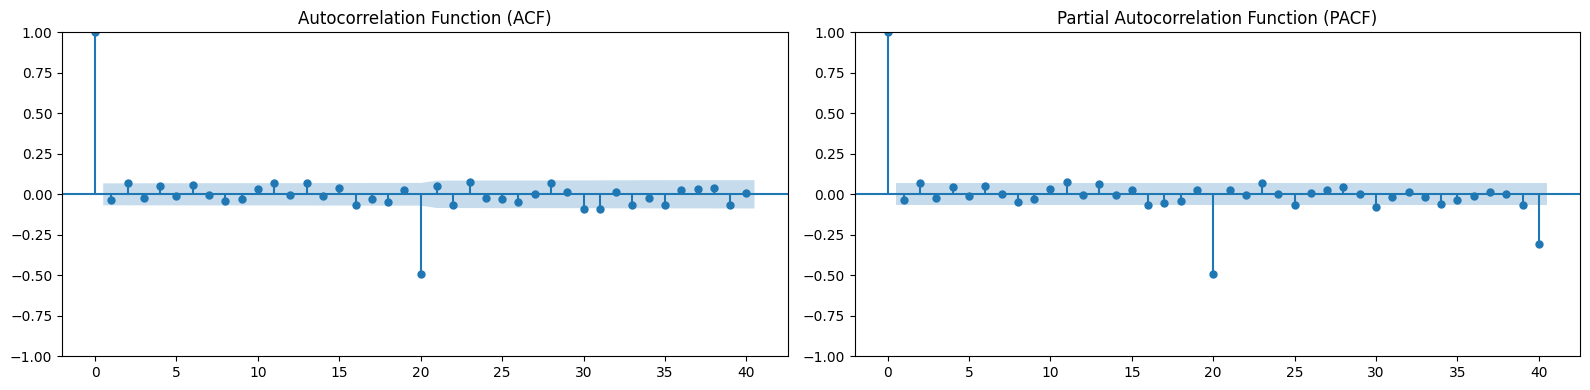


===========Ticker: WEC===========


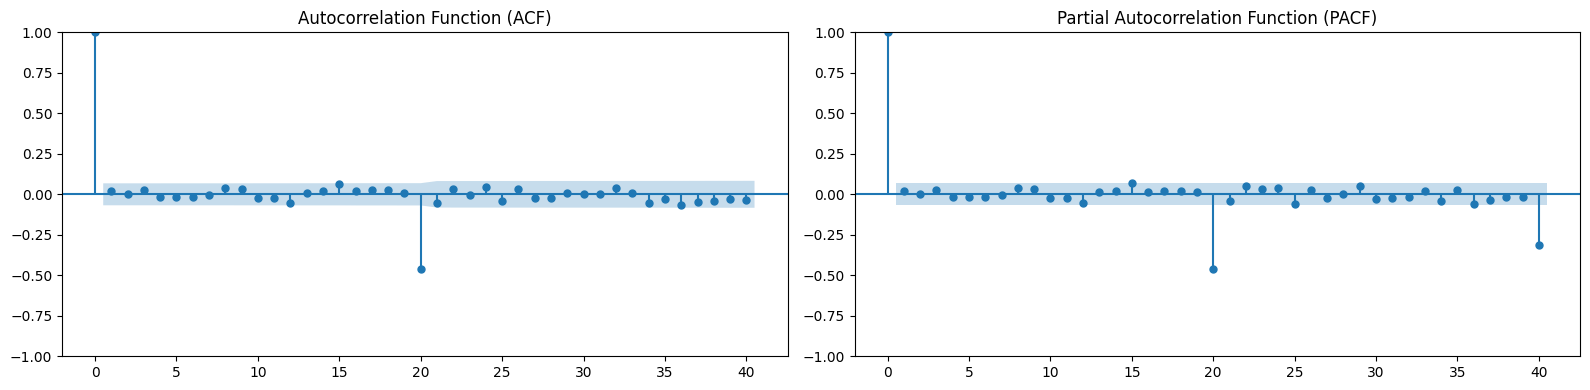


===========Ticker: WELL===========


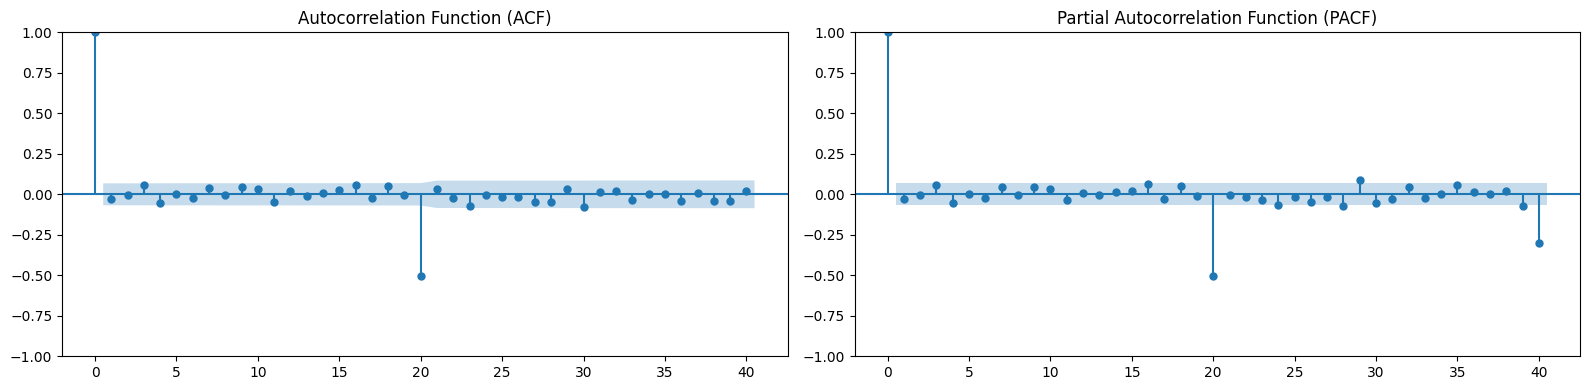


===========Ticker: WY===========


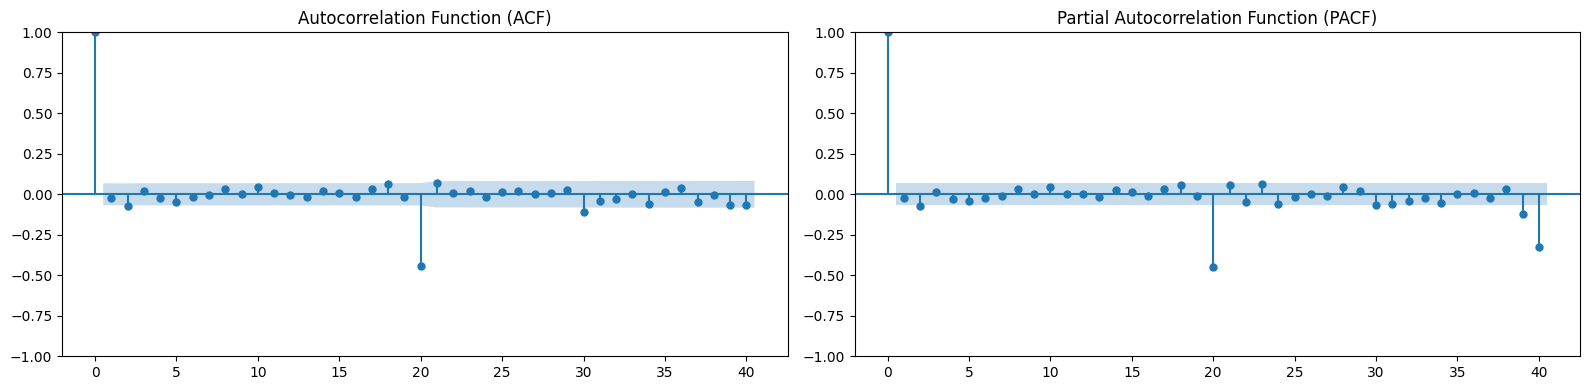

In [ ]:
for ticker in train['ticker'].unique():

  print(f"\n===========Ticker: {ticker}===========")

  data = train[train['ticker'] == ticker].copy()
  data = data.sort_values('date')
  data['target_Diff'] = data['target'].diff()

  # Plot ACF and PACF for the differenced series
  fig, axes = plt.subplots(1, 2, figsize=(16, 4))

  # ACF plot
  plot_acf(data['target_Diff'].dropna(), lags=40, ax=axes[0])
  axes[0].set_title('Autocorrelation Function (ACF)')

  # PACF plot
  plot_pacf(data['target_Diff'].dropna(), lags=40, ax=axes[1])
  axes[1].set_title('Partial Autocorrelation Function (PACF)')

  plt.tight_layout()
  plt.show()

# Train and Forecast (ARIMA)

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA


def full_panel_rolling_forecasts(df, test):
    all_forecasts = []

    for ticker in df['ticker'].unique():

        # filter data (full and test) for each ticker


        df_ticker = df[df['ticker'] == ticker][['target', 'date']].set_index('date').asfreq('D').asfreq('B').ffill()
        test_dates = test[test['ticker'] == ticker][['target', 'date']].set_index('date').asfreq('D').asfreq('B').ffill()

        '''
        აქ ffill-ს ვიყენებ, რადგან asfreq('B') - ამ მეთოდის სამუშაო (არაკალენდარული) დღეები უფრო მეტია, ვიდრე ჩვენი დატის დღეები
        და ARIMA ერორს წერს არასწორი ინდექსისთვის, ვერ აforecast-ებს. არ არის წესით სწორი ეგრე შევსება, მაგრამ ჯერჯერობით
        სხვა გამოსავალი ვერ მოვიფიქრე
        '''

        for test_date in test_dates.index:

            #Looks at past data (for each day in test, train becomes train + 1 day)
            df_train = df_ticker[df_ticker.index < test_date]

            try:
                model = ARIMA(df_train['target'], order=(1, 0, 1))
                fitted = model.fit()
                # Get residuals

                residuals = fitted.resid

                # Ljung-Box test
                ljung_results = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
                print(ljung_results)

                forecast = fitted.forecast(steps=1).iloc[0]

                all_forecasts.append({
                    'ticker': ticker,
                    'forecast_date': test_date,
                    'pred': forecast
                })
            except:
                continue  # Skip if ARIMA fails

    return pd.DataFrame(all_forecasts)


In [ ]:
forecast_df = full_panel_rolling_forecasts(df, test)

Streaming output truncated to the last 5000 lines.
10  12.819547   0.233937
20  45.534240   0.000933
      lb_stat  lb_pvalue
10  12.831785   0.233230
20  45.748770   0.000873
      lb_stat  lb_pvalue
10  12.937836   0.227168
20  45.931094   0.000824
      lb_stat  lb_pvalue
10  13.021744   0.222459
20  45.959624   0.000816
      lb_stat  lb_pvalue
10  12.875657   0.230707
20  49.690142   0.000245
      lb_stat  lb_pvalue
10  12.892214   0.229761
20  49.755583   0.000240
      lb_stat  lb_pvalue
10  12.905328   0.229013
20  49.809824   0.000236
      lb_stat  lb_pvalue
10  12.814794   0.234212
20  49.640169   0.000249
      lb_stat  lb_pvalue
10  12.820145   0.233902
20  49.704809   0.000244
      lb_stat  lb_pvalue
10  12.848544   0.232264
20  49.778626   0.000238
      lb_stat  lb_pvalue
10  12.789583   0.235676
20  49.793374   0.000237
      lb_stat  lb_pvalue
10  12.921862   0.228073
20  49.947778   0.000225
      lb_stat  lb_pvalue
10  13.045387   0.221145
20  50.217845   0.000206

In [ ]:
forecast_df

,ticker,forecast_date,pred
0,A,2024-05-01,-4.639593
1,A,2024-05-02,-3.285077
2,A,2024-05-03,-2.522973
3,A,2024-05-06,-3.028085
4,A,2024-05-07,-2.487443
...,...,...,...
10555,WY,2025-03-26,-2.480411
10556,WY,2025-03-27,-0.624246
10557,WY,2025-03-28,-0.813925
10558,WY,2025-03-31,-1.664058


In [ ]:
forecast_df.to_excel('ARIMA.xlsx')

In [ ]:
test_target = []
for ticker in test['ticker'].unique():
  test_dates = test[test['ticker'] == ticker][['ticker','target_for_test', 'date']].set_index('date').asfreq('D').asfreq('B').reset_index()
  test_target.append(test_dates)

In [ ]:
train_target = []
for ticker in train['ticker'].unique():
  train_nan = train[train['ticker'] == ticker][['ticker','target_for_test', 'date']].set_index('date').asfreq('D').asfreq('B').ffill().reset_index()
  train_target.append(train_nan)

In [ ]:
forecast_df['target'] = pd.concat(test_target).reset_index()['target_for_test']

In [ ]:
forecast_df

,ticker,forecast_date,pred,target
0,A,2024-05-01,-4.639593,-5.241906
1,A,2024-05-02,-3.285077,-5.170157
2,A,2024-05-03,-2.522973,-5.772678
3,A,2024-05-06,-3.028085,-6.941185
4,A,2024-05-07,-2.487443,-5.457634
...,...,...,...,...
10555,WY,2025-03-26,-2.480411,-13.324269
10556,WY,2025-03-27,-0.624246,-16.154106
10557,WY,2025-03-28,-0.813925,-12.908719
10558,WY,2025-03-31,-1.664058,-11.919399


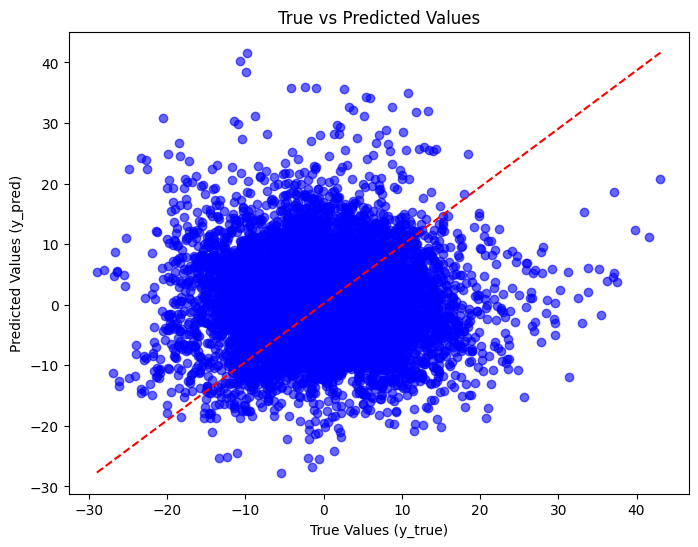

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(forecast_df['target'], forecast_df['pred'], color='blue', alpha=0.6)
plt.plot([min(forecast_df['target']), max(forecast_df['target'])], [min(forecast_df['pred']), max(forecast_df['pred'])], color='red', linestyle='--')  # Line for perfect prediction
plt.xlabel('True Values (y_true)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('True vs Predicted Values')
plt.show()

In [ ]:
forecast_df.dropna(inplace = True)

In [ ]:
rmse = np.sqrt(mean_squared_error(forecast_df['target'], forecast_df['pred']))

print(f'RMSE (test): {rmse:.5f}')

test_r2 = r2_score(forecast_df['target'], forecast_df['pred'])

print(f"Test R²: {test_r2:.4f}")


# Define your threshold (e.g., 5% = 0.05)
threshold = 0.05

# Only consider predictions where the absolute predicted or actual value exceeds the threshold
mask = (np.abs(forecast_df['pred']) >= threshold) | (np.abs(forecast_df['target'].values) >= threshold)

# Directional accuracy: match of signs
directional_hits = np.sign(forecast_df['pred'][mask]) == np.sign(forecast_df['target'].values[mask])
directional_accuracy = np.mean(directional_hits)

print(f"Directional Accuracy (|return| ≥ {threshold*100:.0f}%):", directional_accuracy)

RMSE (test): 10.79492
Test R²: -0.8590
Directional Accuracy (|return| ≥ 5%): 0.49970355731225297


In [ ]:
arima = pd.read_excel('/content/drive/MyDrive/Thesis_Data/ARIMA (1,0,1).xlsx')

In [ ]:
arima['residual'] = arima['target'] - arima['pred']

In [ ]:
mae_list =[]
rmse_list = []
r2_list = []
dir_acc = []
for ticker in arima['ticker'].unique():
    print(f"\n===========Ticker: {ticker}===========")

    mae = mean_absolute_error(arima['target'], arima['pred'])
    mae_list.append(mae)
    print(f'MAE: {mae:.5f}')

    rmse = np.sqrt(mean_squared_error(arima['target'], arima['pred']))
    rmse_list.append(rmse)
    print(f'RMSE: {rmse:.5f}')

    r2 = r2_score(arima['target'], arima['pred'])
    r2_list.append(r2)
    print(f"R²: {r2:.4f}")


    # Define your threshold (e.g., 5% = 0.05)
    threshold = 0.05

    # Only consider predictions where the absolute predicted or actual value exceeds the threshold
    mask = (np.abs(arima['pred']) >= threshold) | (np.abs(arima['target'].values) >= threshold)

    # Directional accuracy: match of signs
    directional_hits = np.sign(arima['pred'][mask]) == np.sign(arima['target'].values[mask])
    directional_accuracy = np.mean(directional_hits)
    dir_acc.append(directional_accuracy)
    print(f"Directional Accuracy (|return| ≥ {threshold*100:.0f}%):", directional_accuracy)



===========Ticker: A===========
MAE: 8.33293
RMSE: 10.79492
R²: -0.8590
Directional Accuracy (|return| ≥ 5%): 0.49970355731225297

===========Ticker: ABT===========
MAE: 8.33293
RMSE: 10.79492
R²: -0.8590
Directional Accuracy (|return| ≥ 5%): 0.49970355731225297

===========Ticker: ADM===========
MAE: 8.33293
RMSE: 10.79492
R²: -0.8590
Directional Accuracy (|return| ≥ 5%): 0.49970355731225297

===========Ticker: AES===========
MAE: 8.33293
RMSE: 10.79492
R²: -0.8590
Directional Accuracy (|return| ≥ 5%): 0.49970355731225297

===========Ticker: AMZN===========
MAE: 8.33293
RMSE: 10.79492
R²: -0.8590
Directional Accuracy (|return| ≥ 5%): 0.49970355731225297

===========Ticker: APA===========
MAE: 8.33293
RMSE: 10.79492
R²: -0.8590
Directional Accuracy (|return| ≥ 5%): 0.49970355731225297

===========Ticker: APD===========
MAE: 8.33293
RMSE: 10.79492
R²: -0.8590
Directional Accuracy (|return| ≥ 5%): 0.49970355731225297

===========Ticker: BA===========
MAE: 8.33293
RMSE: 10.79492
R²: -0.8

In [ ]:
print(np.array(mae_list).mean())
print(np.array(rmse_list).mean())
print(np.array(r2_list).mean())
print(np.array(dir_acc).mean())

8.332926915435225
10.794923175984701
-0.8589880330888294
0.4997035573122528


In [ ]:
arima

,Unnamed: 0,ticker,forecast_date,pred,target
0,0,A,2024-05-01,-4.639593,-5.241906
1,1,A,2024-05-02,-3.285077,-5.170157
2,2,A,2024-05-03,-2.522973,-5.772678
3,3,A,2024-05-06,-3.028085,-6.941185
4,4,A,2024-05-07,-2.487443,-5.457634
...,...,...,...,...,...
10115,10555,WY,2025-03-26,-2.480411,-13.324269
10116,10556,WY,2025-03-27,-0.624246,-16.154106
10117,10557,WY,2025-03-28,-0.813925,-12.908719
10118,10558,WY,2025-03-31,-1.664058,-11.919399


In [ ]:
for ticker in arima['ticker'].unique():
    data = train[train['ticker'] == ticker].sort_values('date')
    model = ARIMA(data['adjClose'], order=(1, 1, 1))  # example order
    fitted = model.fit()
    residuals = fitted.resid
    lb_test = acorr_ljungbox(residuals, lags=[20], return_df=True)
    print(f"{ticker}: p-value = {lb_test['lb_pvalue'].iloc[0]}")
